# Verify Model Improvement over Loop 1 After Loop 2.

## Prepare the Notebook.

In [1]:
import logging
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

from sc_exp_design.metrics import compute_e_distance, compute_mmd

### Add Extra Environmental Variables.

In [2]:
sys.path.insert(0, "../../../../../shared_utils")
from experiment_utils import get_forward_model, generate_with_condition
from plot_utils import make_scatter_plot

### Setup Logger.

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] - %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger(__name__)


## Load Model from Loop 1.

### Load Configurations from Loop 1.

In [6]:
with hydra.initialize(
    config_path="../../../../../inverse/loss_guidance/config",
    version_base=None
):
    config_loop1 = hydra.compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus"
        ]
    )
scatter_cols = config_loop1.annotation.scatter_columns
protocol_cols = config_loop1.annotation.protocol_columns

### Load Loop 1 Model.

In [5]:
forward_model_loop1, (
    pert_resp_prediction_model_loop1,
    target_prediction_model_loop1
) = get_forward_model(config_loop1, logger=logger)
pert_resp_prediction_model_loop1.velocity_field.eval()
target_prediction_model_loop1.target_prediction_model.eval()


[2026-06-18 19:39:20] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
[2026-06-18 19:40:51] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
 

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

### Fit Label Encoder.

In [6]:
train_adata_g = target_prediction_model_loop1.train_data.adata
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())


## Load Model from Loop 2.

### Load Configurations from Loop 2.

In [7]:
with hydra.initialize(
    config_path="../../../../../inverse/loss_guidance/config",
    version_base=None
):
    config_loop2 = hydra.compose(
        config_name="run_inverse",
        overrides=[
            "annotation=bloodplus",
            "paths=bloodplus_loop2",
            "paths.perturbation_prediction_path=/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/forward_model/loop2/2026-06-17_17-19-47/fresh-bee-21_FlowMatching.pkl"
        ]
    )

### Load Loop 2 Model.

In [8]:
forward_model_loop2, (
    pert_resp_prediction_model_loop2,
    target_prediction_model_loop2
) = get_forward_model(config_loop2, logger=logger)
pert_resp_prediction_model_loop2.velocity_field.eval()
target_prediction_model_loop2.target_prediction_model.eval()


[2026-06-18 19:40:52] - __main__: Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/forward_model/loop2/2026-06-17_17-19-47/fresh-bee-21_FlowMatching.pkl...
[2026-06-18 19:42:54] - __main__: Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.0, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type_leiden): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)

## Prepare Condition Data from Loop 2.5

### Read Residual Data from Loop 2.5

In [4]:
loop2p5_res_h5ad_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2p5/replicate/adata_500k_residual.h5ad"
adata_res_loop2p5 = sc.read_h5ad(loop2p5_res_h5ad_path)
adata_res_loop2p5

AnnData object with n_obs × n_vars = 500000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps'
    layers: 'positives', 'raw'

### Retrieve Original Data.

In [7]:
X_channel = adata_res_loop2p5.X
X_scatter = adata_res_loop2p5.obs[scatter_cols].astype(float).values
X = np.concatenate((X_channel, X_scatter), axis=1)
print(f"{X_channel.shape=}, {X_scatter.shape=}, {X.shape=}")

X_channel.shape=(500000, 20), X_scatter.shape=(500000, 6), X.shape=(500000, 26)


### Prepare Condition Data.

In [8]:
meta_df_loop2p5 = adata_res_loop2p5.obs
cond_data =  meta_df_loop2p5[protocol_cols].astype(float).values
X_cond = np.unique(cond_data, axis=0)
X_cond.shape

(4, 12)

### Mean Variance Plot per Experiment.

4it [00:00, 50.39it/s]


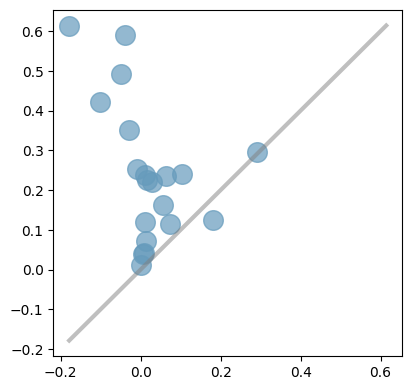

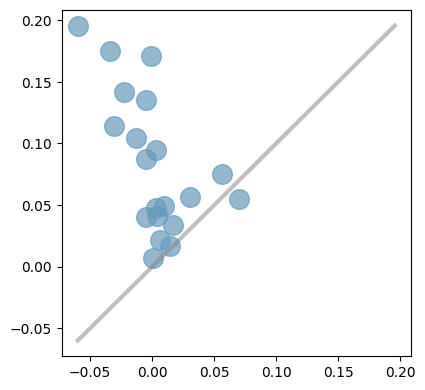

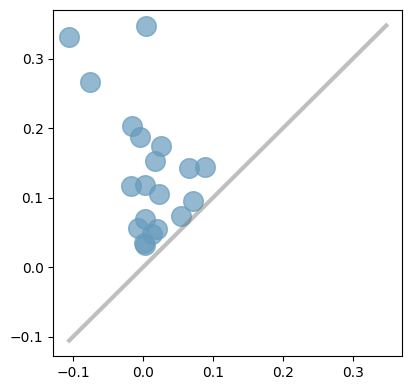

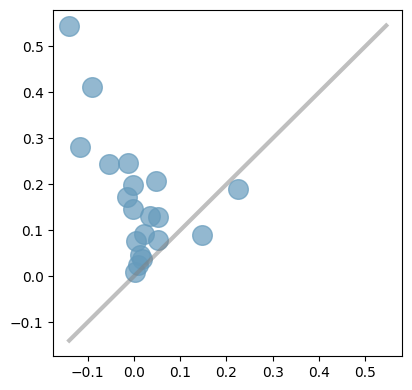

In [11]:
# ---- Define color for plotting ----
color_loop1 = '#669bbc'   # light blue

# ---- Iterate over unique conditions ----
for idx, cond in tqdm(enumerate(X_cond)):
    # ---- Get mask for current condition ----
    cond_idxs = np.all(cond_data == cond, axis=1)

    # ========================================================= #
    # ===================== REAL ============================== #
    # ========================================================= #
    # ---- Get Real data ----
    x_channel = X_channel[cond_idxs]

    # ---- Compute statistics ----
    x_chann_mean = x_channel.mean(0)
    x_chann_std = x_channel.std(0)

    # ---- Mean-Var Plot ----
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(x_chann_mean, x_chann_std, color=color_loop1, alpha=0.7, s=200, label='_nolegend_')

    # ---- Diagonal reference line for mean ----
    all_vals = np.concatenate([x_chann_mean, x_chann_std])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax.plot([min_val, max_val], [min_val, max_val], linewidth=3, alpha=0.5, label='_nolegend_',color="gray")


### Compute Neighbors and UMAP.

In [10]:
sc.pp.neighbors(adata_res_loop2p5)
sc.tl.umap(adata_res_loop2p5)

### Plot UMAP by Experiment Number.

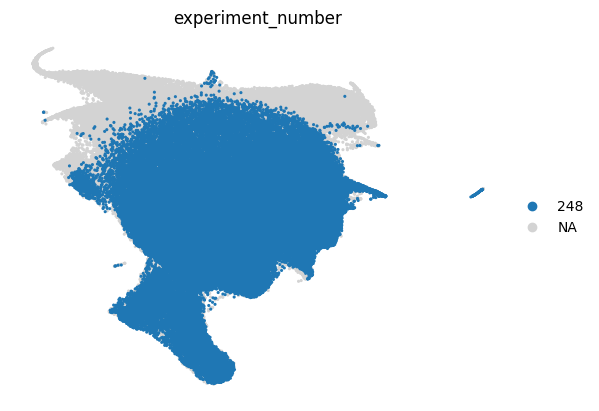

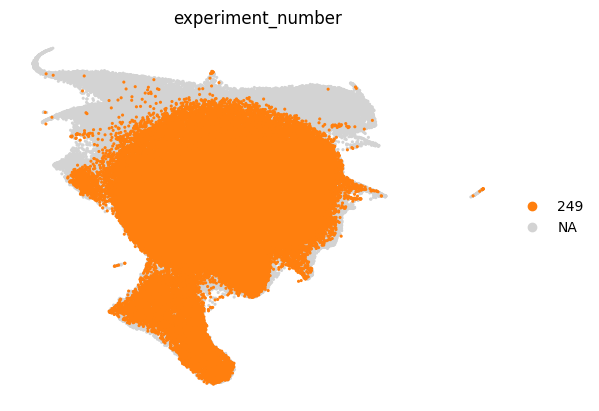

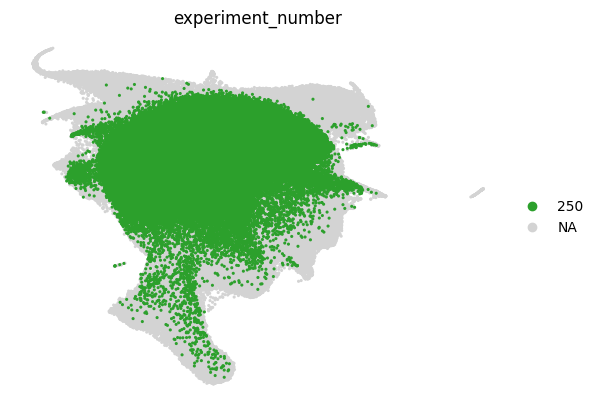

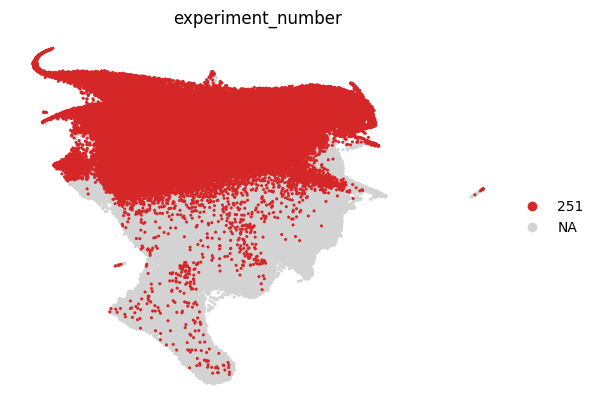

In [11]:
exp_numbers = sorted(adata_res_loop2p5.obs.experiment_number.unique())
for exp in exp_numbers:
    sc.pl.embedding(adata_res_loop2p5, "umap", s=20, groups=exp, color=["experiment_number"], frameon=False)

### Plot UMAP by Marker Value.

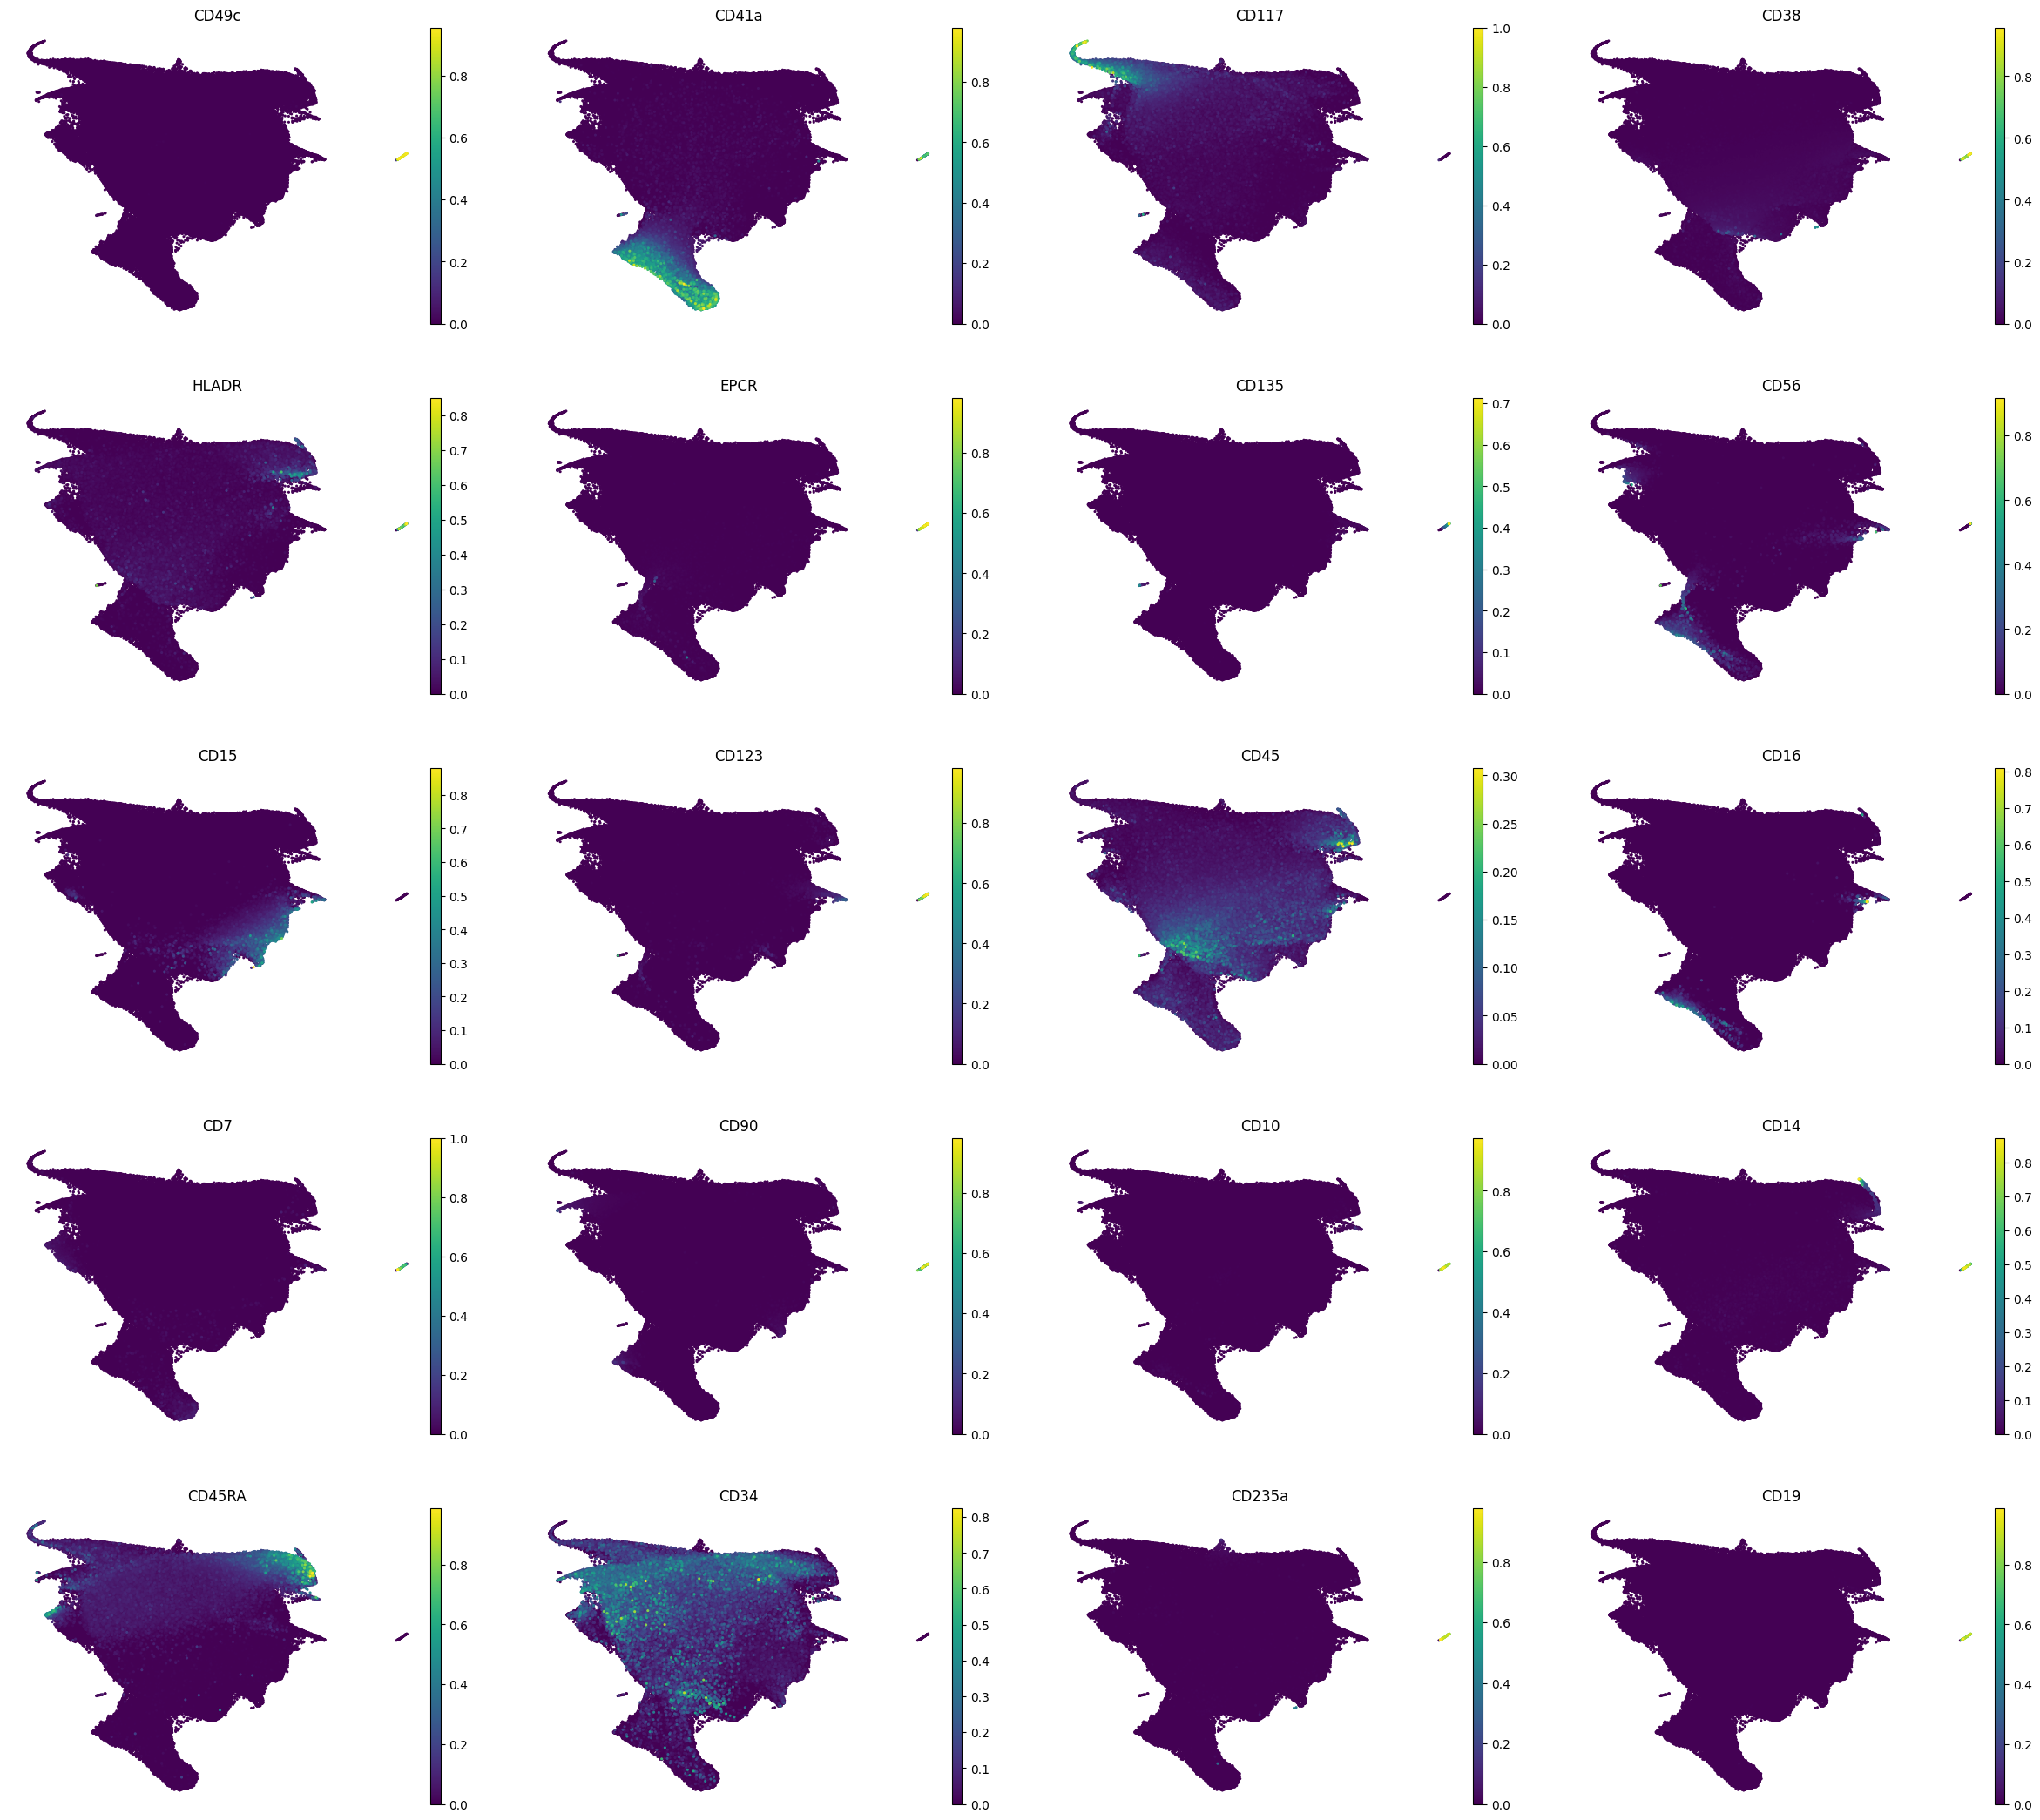

In [12]:
sc.pl.embedding(adata_res_loop2p5, "umap", s=20, color=adata_res_loop2p5.var_names, frameon=False)

## Classify Data.

### Classify with Loop 1 Model.

In [14]:
# ---- Get standardization parameters ----
adata_g_loop1 = target_prediction_model_loop1.train_data.adata
loop1_channel_params_g = adata_g_loop1.uns["X_channel_params"]
loop1_scatter_params_g = adata_g_loop1.uns["X_scatter_params"]

# ---- Apply Standardization ----
X_channel_real_trasnf1_g = (X_channel - loop1_channel_params_g["mean"])/loop1_channel_params_g["std"]
X_scatter_real_trasnf1_g = (X_scatter - loop1_scatter_params_g["mean"])/loop1_scatter_params_g["std"]
X_real_trasnf1_g = np.concatenate((X_channel_real_trasnf1_g, X_scatter_real_trasnf1_g), axis=1)
X_torch_trasnf1_g = torch.from_numpy(X_real_trasnf1_g).to(torch.float32)

# ----- Create dataset for classification ----
dataset_g_loop1 = TensorDataset(X_torch_trasnf1_g)
dataloader_loop1 = DataLoader(dataset_g_loop1, batch_size=10_000, shuffle=False)

# ---- List to store the predictions ----
ct_preds_loop1 = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader_loop1):
        xb = xb[0]
        xb = xb.to(target_prediction_model_loop1.device)
        y_pred = target_prediction_model_loop1.predict(xb)["cell_type"].argmax(1)
        ct_preds_loop1.append(y_pred.cpu().detach().numpy())
ct_preds_loop1 = np.concatenate(ct_preds_loop1)

# ---- Decode predicted cell types ----
ct_preds_loop1 = classes[ct_preds_loop1]

# ---- Write back to anndata ----
adata_res_loop2p5.obs["cell_type_loop1"] = ct_preds_loop1
adata_res_loop2p5

100%|██████████| 50/50 [00:06<00:00,  7.29it/s]


AnnData object with n_obs × n_vars = 500000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type_loop1'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'neighbors', 'u

### Classify with Loop 2 Model.

In [15]:
# ---- Get standardization parameters ----
adata_g_loop2 = target_prediction_model_loop2.train_data.adata
loop2_channel_params_g = adata_g_loop2.uns["X_channel_params"]
loop2_scatter_params_g = adata_g_loop2.uns["X_scatter_params"]

# ---- Apply Standardization ----
X_channel_real_trasnf2_g = (X_channel - loop2_channel_params_g["mean"])/loop2_channel_params_g["std"]
X_scatter_real_trasnf2_g = (X_scatter - loop2_scatter_params_g["mean"])/loop2_scatter_params_g["std"]
X_real_trasnf2_g = np.concatenate((X_channel_real_trasnf2_g, X_scatter_real_trasnf2_g), axis=1)
X_torch_trasnf2_g = torch.from_numpy(X_real_trasnf2_g).to(torch.float32)

# ----- Create dataset for classification ----
dataset_g_loop2 = TensorDataset(X_torch_trasnf2_g)
dataloader_loop2 = DataLoader(dataset_g_loop2, batch_size=10_000, shuffle=False)

# ---- List to store the predictions ----
ct_preds_loop2 = []

# ---- Classify cell types ---
with torch.no_grad():
    for xb in tqdm(dataloader_loop2):
        xb = xb[0]
        xb = xb.to(target_prediction_model_loop2.device)
        y_pred = target_prediction_model_loop2.predict(xb)["cell_type_leiden"].argmax(1)
        ct_preds_loop2.append(y_pred.cpu().detach().numpy())
ct_preds_loop2 = np.concatenate(ct_preds_loop2)

# ---- Decode predicted cell types ----
ct_preds_loop2 = classes[ct_preds_loop2]

# ---- Write back to anndata ----
adata_res_loop2p5.obs["cell_type_loop2"] = ct_preds_loop2
adata_res_loop2p5

100%|██████████| 50/50 [00:02<00:00, 17.53it/s]


AnnData object with n_obs × n_vars = 500000 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'cell_type_loop1', 'cell_type_loop2'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'meta', 'processing_step

### Plot UMAP by Predicted Cell Type.

... storing 'cell_type_loop1' as categorical
... storing 'cell_type_loop2' as categorical


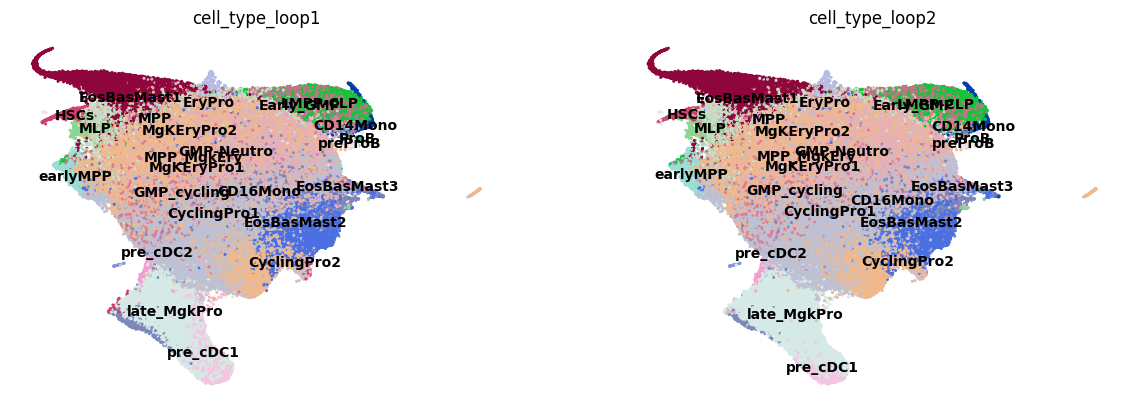

In [16]:
sc.pl.embedding(adata_res_loop2p5, "umap", s=20, color=["cell_type_loop1", "cell_type_loop2"], frameon=False, legend_loc="on data")

## Run Predictions with Alternative Models.

### Define Shared Settings for Prediction.

In [ ]:
num_samples = 20_000
num_time_steps = 1000
solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}

### Predict With Loop 1 Model.

In [19]:
pred_loop1 = generate_with_condition(
    X_cond,
    forward_model_loop1,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_samples,
    logger=logger,
    cell_type_column="cell_type"
)

[2026-06-18 19:53:28] - __main__: X_gen.shape=(20000, 4, 26), X_channel_gen.shape=(20000, 4, 20), X_scatter_gen.shape=(20000, 4, 6), gen_ct_logits.shape=(20000, 4, 24)


### Parse Prediction Results and Rescale.

In [20]:
# ---- Parse Prediction Dictionaries ----
X_gen_loop1_transf = pred_loop1["X"]
X_channel_gen_loop1_trans = pred_loop1["X_channel"]
X_scatter_gen_loop1_trans = pred_loop1["X_scatter"]
ct_probs_gen_loop1_trans = pred_loop1["ct_probs"]
print(f"{X_gen_loop1_transf.shape=}, {X_channel_gen_loop1_trans.shape=}, {X_scatter_gen_loop1_trans.shape=}, {ct_probs_gen_loop1_trans.shape=}")

# ---- Get standardization parameters ----
adata_phi_loop1 = pert_resp_prediction_model_loop1.train_data.adata
loop1_channel_params = adata_phi_loop1.uns["X_channel_params"]
loop1_scatter_params = adata_phi_loop1.uns["X_scatter_params"]

# ---- Inverse transform on generated data ----
X_channel_gen_loop1 = X_channel_gen_loop1_trans*loop1_channel_params["std"] + loop1_channel_params["mean"]
X_scatter_gen_loop1 = X_scatter_gen_loop1_trans*loop1_scatter_params["std"] + loop1_scatter_params["mean"]
X_gen_loop1 = np.concatenate((X_channel_gen_loop1, X_scatter_gen_loop1), axis=2)

X_gen_loop1_transf.shape=(20000, 4, 26), X_channel_gen_loop1_trans.shape=(20000, 4, 20), X_scatter_gen_loop1_trans.shape=(20000, 4, 6), ct_probs_gen_loop1_trans.shape=(20000, 4, 24)


### Predict With Loop 2 Model.

In [21]:
pred_loop2 = generate_with_condition(
    X_cond,
    forward_model_loop2,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_samples,
    logger=logger,
    cell_type_column="cell_type_leiden"
)

[2026-06-18 19:54:12] - __main__: X_gen.shape=(20000, 4, 26), X_channel_gen.shape=(20000, 4, 20), X_scatter_gen.shape=(20000, 4, 6), gen_ct_logits.shape=(20000, 4, 24)


### Parse Prediction Results and Rescale.

In [22]:
# ---- Parse Prediction Dictionaries ----
X_gen_loop2_transf = pred_loop2["X"]
X_channel_gen_loop2_trans = pred_loop2["X_channel"]
X_scatter_gen_loop2_trans = pred_loop2["X_scatter"]
ct_probs_gen_loop2_trans = pred_loop2["ct_probs"]
print(f"{X_gen_loop2_transf.shape=}, {X_channel_gen_loop2_trans.shape=}, {X_scatter_gen_loop2_trans.shape=}, {ct_probs_gen_loop2_trans.shape=}")

# ---- Get standardization parameters ----
adata_phi_loop2 = pert_resp_prediction_model_loop2.train_data.adata
loop2_channel_params = adata_phi_loop2.uns["X_channel_params"]
loop2_scatter_params = adata_phi_loop2.uns["X_scatter_params"]

# ---- Inverse transform on generated data ----
X_channel_gen_loop2 = X_channel_gen_loop2_trans*loop2_channel_params["std"] + loop2_channel_params["mean"]
X_scatter_gen_loop2 = X_scatter_gen_loop2_trans*loop2_scatter_params["std"] + loop2_scatter_params["mean"]
X_gen_loop2 = np.concatenate((X_channel_gen_loop2, X_scatter_gen_loop2), axis=2)

X_gen_loop2_transf.shape=(20000, 4, 26), X_channel_gen_loop2_trans.shape=(20000, 4, 20), X_scatter_gen_loop2_trans.shape=(20000, 4, 6), ct_probs_gen_loop2_trans.shape=(20000, 4, 24)


## Evaluate Prediction Quality on Cell State Space.

### Transform with Loop 1 Parameters.

In [23]:
X_channel_real_trasnf1 = (X_channel - loop1_channel_params["mean"])/loop1_channel_params["std"]
X_scatter_real_trasnf1 = (X_scatter - loop1_scatter_params["mean"])/loop1_scatter_params["std"]
X_real_trasnf1 = np.concatenate((X_channel_real_trasnf1, X_scatter_real_trasnf1), axis=1)

### Transform with Loop 2 Parameters.

In [24]:
X_channel_real_trasnf2 = (X_channel - loop2_channel_params["mean"])/loop2_channel_params["std"]
X_scatter_real_trasnf2 = (X_scatter - loop2_scatter_params["mean"])/loop2_scatter_params["std"]
X_real_trasnf2 = np.concatenate((X_channel_real_trasnf2, X_scatter_real_trasnf2), axis=1)

### Group the Data for Each Protocol and Compute Metrics.

In [25]:
# ---- Subset strategy ----
n_obs_eval = 1_000

# ---- Store for records ----
records = []

# ---- Iterate over unique conditions ----
for idx, cond in tqdm(enumerate(X_cond)):
    # ---- Get mask for current condition ----
    cond_idxs = np.all(cond_data == cond, axis=1)

    # ---- Get Real data ----
    x = X[cond_idxs][:n_obs_eval]
    x_channel = X_channel[cond_idxs][:n_obs_eval]
    x_scatter = X_scatter[cond_idxs][:n_obs_eval]

    # ========================================================= #
    # ==================== LOOP 1 ============================= #
    # ========================================================= #

    # ---- Loop 1 generated data ----
    X_loop1_cond_gen = X_gen_loop1[:, idx][:n_obs_eval]
    X_channel_loop1_cond_gen = X_channel_gen_loop1[:, idx][:n_obs_eval]
    X_scatter_loop1_cond_gen = X_scatter_gen_loop1[:, idx][:n_obs_eval]

    # ---- Compute energy distance -----
    edist_loop1_X = compute_e_distance(x, X_loop1_cond_gen).item()
    edist_loop1_X_channel = compute_e_distance(x_channel, X_channel_loop1_cond_gen).item()
    edist_loop1_X_scatter = compute_e_distance(x_scatter, X_scatter_loop1_cond_gen).item()

    # ---- Compute MMD -----
    mmd_loop1_X = compute_mmd(x, X_loop1_cond_gen).item()
    mmd_loop1_X_channel = compute_mmd(x_channel, X_channel_loop1_cond_gen).item()
    mmd_loop1_X_scatter = compute_mmd(x_scatter, X_scatter_loop1_cond_gen).item()

    # ========================================================= #
    # ==================== LOOP 2 ============================= #
    # ========================================================= #
    # ---- Loop 2 generated data ----
    X_loop2_cond_gen = X_gen_loop2[:, idx][:n_obs_eval]
    X_channel_loop2_cond_gen = X_channel_gen_loop2[:, idx][:n_obs_eval]
    X_scatter_loop2_cond_gen = X_scatter_gen_loop2[:, idx][:n_obs_eval]

    # ---- Compute energy distance -----
    edist_loop2_X = compute_e_distance(x, X_loop2_cond_gen).item()
    edist_loop2_X_channel = compute_e_distance(x_channel, X_channel_loop2_cond_gen).item()
    edist_loop2_X_scatter = compute_e_distance(x_scatter, X_scatter_loop2_cond_gen).item()

    # ---- Compute MMD -----
    mmd_loop2_X = compute_mmd(x, X_loop2_cond_gen).item()
    mmd_loop2_X_channel = compute_mmd(x_channel, X_channel_loop2_cond_gen).item()
    mmd_loop2_X_scatter = compute_mmd(x_scatter, X_scatter_loop2_cond_gen).item()

    # ---- Update records ----
    records.append(
        {
            "edist_X_loop1": edist_loop1_X,
            "edist_X_channel_loop1": edist_loop1_X_channel,
            "edist_X_scatter_loop1": edist_loop1_X_scatter,

            "edist_X_loop2": edist_loop2_X,
            "edist_X_channel_loop2": edist_loop2_X_channel,
            "edist_X_scatter_loop2": edist_loop2_X_scatter,

            "mmd_X_loop1": mmd_loop1_X,
            "mmd_X_channel_loop1": mmd_loop1_X_channel,
            "mmd_X_scatter_loop1": mmd_loop1_X_scatter,

            "mmd_X_loop2": mmd_loop2_X,
            "mmd_X_channel_loop2": mmd_loop2_X_channel,
            "mmd_X_scatter_loop2": mmd_loop2_X_scatter,
        }
    )

# ---- Create DataFrame with evaluation metrics ----
cell_state_metrics_df = pd.DataFrame(records)
cell_state_metrics_df

4it [00:05,  1.43s/it]


,edist_X_loop1,edist_X_channel_loop1,edist_X_scatter_loop1,edist_X_loop2,edist_X_channel_loop2,edist_X_scatter_loop2,mmd_X_loop1,mmd_X_channel_loop1,mmd_X_scatter_loop1,mmd_X_loop2,mmd_X_channel_loop2,mmd_X_scatter_loop2
0,4.128725e+12,79.878203,4.128725e+12,3.342673e+12,910.199138,3.342673e+12,0.002,0.678305,0.002,0.002,1.255745,0.002
1,1.918845e+14,15714.692780,1.918845e+14,1.182038e+15,829432.927230,1.182038e+15,0.002,1.299425,0.002,0.002,1.490004,0.002
2,6.639139e+13,4810.422842,6.639139e+13,8.706295e+14,342614.709660,8.706295e+14,0.002,1.232514,0.002,0.002,1.434836,0.002
3,3.355429e+12,129.406972,3.355429e+12,5.771109e+12,2174.973519,5.771109e+12,0.002,0.786428,0.002,0.002,1.354815,0.002


### Construct DataFrame with Marker Statistics.

In [ ]:
# ---- Prepare var names ----
var_names = adata_res_loop2p5.var_names.tolist() + scatter_cols

# ---- Store for records ----
records = []

# ---- Iterate over unique conditions ----
for idx, cond in tqdm(enumerate(X_cond)):
    # ---- Get mask for current condition ----
    cond_idxs = np.all(cond_data == cond, axis=1)

    # ========================================================= #
    # ===================== REAL ============================== #
    # ========================================================= #
    # ---- Get Real data ----
    x = X[cond_idxs]
    x_channel = X_channel[cond_idxs]
    x_scatter = X_scatter[cond_idxs]

    # ---- Compute statistics ----
    x_mean = x.mean(0)
    x_std = x.std(0)

    # ---- Get Real data transf 1 ----
    x_trasnf1 = X_real_trasnf1[cond_idxs]
    x_channel_trasnf1 = X_channel_real_trasnf1[cond_idxs]
    x_scatter_trasnf1 = X_scatter_real_trasnf1[cond_idxs]

    # ---- Compute statistics ----
    x_mean_transf1 = x_trasnf1.mean(0)
    x_std_transf1 = x_trasnf1.std(0)

    # ---- Get Real data transf 2 ----
    x_trasnf2 = X_real_trasnf2[cond_idxs]
    x_channel_trasnf2 = X_channel_real_trasnf2[cond_idxs]
    x_scatter_trasnf2 = X_scatter_real_trasnf2[cond_idxs]

    # ---- Compute statistics ----
    x_mean_transf2 = x_trasnf2.mean(0)
    x_std_transf2 = x_trasnf2.std(0)

    # ========================================================= #
    # ==================== LOOP 1 ============================= #
    # ========================================================= #
    # ---- Loop 1 generated data ----
    X_loop1_cond_gen = X_gen_loop1[:, idx]
    X_channel_loop1_cond_gen = X_channel_gen_loop1[:, idx]
    X_scatter_loop1_cond_gen = X_scatter_gen_loop1[:, idx]

    # ---- Compute statistics ----
    X_loop1_cond_mean = X_loop1_cond_gen.mean(0)
    X_loop1_cond_std = X_loop1_cond_gen.std(0)

    # ---- Loop 1 generated data ----
    X_loop1_cond_gen_transf = X_gen_loop1_transf[:, idx]
    X_channel_loop1_cond_gen_transf = X_channel_gen_loop1_trans[:, idx]
    X_scatter_loop1_cond_gen_transf = X_scatter_gen_loop1_trans[:, idx]

    # ---- Compute statistics ----
    X_loop1_cond_mean_transf = X_loop1_cond_gen_transf.mean(0)
    X_loop1_cond_std_transf = X_loop1_cond_gen_transf.std(0)

    # ========================================================= #
    # ==================== LOOP 2 ============================= #
    # ========================================================= #
    # ---- Loop 2 generated data ----
    X_loop2_cond_gen = X_gen_loop2[:, idx]
    X_channel_loop2_cond_gen = X_channel_gen_loop2[:, idx]
    X_scatter_loop2_cond_gen = X_scatter_gen_loop2[:, idx]

    # ---- Compute statistics ----
    X_loop2_cond_mean = X_loop2_cond_gen.mean(0)
    X_loop2_cond_std = X_loop2_cond_gen.std(0)

    # ---- Loop 2 generated data ----
    X_loop2_cond_gen_transf = X_gen_loop2_transf[:, idx]
    X_channel_loop2_cond_gen_transf = X_channel_gen_loop2_trans[:, idx]
    X_scatter_loop2_cond_gen_transf = X_scatter_gen_loop2_trans[:, idx]

    # ---- Compute statistics ----
    X_loop2_cond_mean_transf = X_loop2_cond_gen_transf.mean(0)
    X_loop2_cond_std_transf = X_loop2_cond_gen_transf.std(0)

    # ---- Update records ----
    records.append(
        {

            # ---- Original Scale ----
            **{
                f"{var}_mean_real": x_mean[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop1": X_loop1_cond_mean[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop2": X_loop2_cond_mean[idx] for idx, var in enumerate(var_names)
            },

            **{
                f"{var}_std_real": x_std[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop1": X_loop1_cond_std[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop2": X_loop2_cond_std[idx] for idx, var in enumerate(var_names)
            },

            # ---- Transformed scale loop 1 ----
            **{
                f"{var}_mean_real_transf1": x_mean_transf1[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop1_transf": X_loop1_cond_mean_transf[idx] for idx, var in enumerate(var_names)
            },

            **{
                f"{var}_std_real_transf1": x_std_transf1[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop1_transf": X_loop1_cond_std_transf[idx] for idx, var in enumerate(var_names)
            },

            # ---- Transformed scale loop 2 ----
            **{
                f"{var}_mean_real_transf2": x_mean_transf2[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_mean_loop2_transf": X_loop2_cond_mean_transf[idx] for idx, var in enumerate(var_names)
            },

            **{
                f"{var}_std_real_transf2": x_std_transf2[idx] for idx, var in enumerate(var_names)
            },
            **{
                f"{var}_std_loop2_transf": X_loop2_cond_std_transf[idx] for idx, var in enumerate(var_names)
            },
        }
    )

# ---- Create DataFrame with evaluation metrics ----
markers_stats_df = pd.DataFrame(records)
markers_stats_df

4it [00:00, 10.84it/s]


,CD49c_mean_real,CD41a_mean_real,CD117_mean_real,CD38_mean_real,HLADR_mean_real,EPCR_mean_real,CD135_mean_real,CD56_mean_real,CD15_mean_real,CD123_mean_real,...,CD45RA_std_loop2_transf,CD34_std_loop2_transf,CD235a_std_loop2_transf,CD19_std_loop2_transf,FSC-A :: FSC - Area_std_loop2_transf,FSC-H :: FSC - Height_std_loop2_transf,FSC-W :: FSC - Width_std_loop2_transf,SSC-A :: SSC - Area_std_loop2_transf,SSC-H :: SSC - Height_std_loop2_transf,SSC-W :: SSC - Width_std_loop2_transf
0,0.027781,0.064002,0.006158,0.291682,0.009443,0.073276,-0.038262,0.014975,0.102962,0.011657,...,1.026214,1.155077,0.912868,1.039114,0.882108,0.762810,1.077644,0.931465,1.057811,0.824201
1,0.009704,0.003737,0.014164,0.056051,0.006239,0.016410,-0.033575,-0.012724,-0.004921,-0.005202,...,0.911249,1.082788,0.908315,0.979576,0.804749,0.797401,1.038543,0.739508,0.892814,0.822697
2,-0.016613,0.002297,0.065941,-0.007991,0.019291,0.012726,0.004768,0.002852,0.000634,0.023410,...,0.887449,1.103446,0.904177,1.061745,0.765224,0.792878,0.968781,0.717021,0.852883,0.810265
3,0.022106,0.047622,0.008993,0.224276,0.016804,0.052836,-0.089664,-0.015681,0.034686,-0.001873,...,0.817259,1.147859,0.869400,1.060514,0.767798,0.780830,1.075995,0.871094,1.062641,0.814934


### Get Statistics of Interest.

In [27]:
# ---- Prepare var names to plot ----
var_names_to_plot = adata_res_loop2p5.var_names.tolist()

# ---- Mean values per marker ----
real_marker_mean = markers_stats_df[[f"{var}_mean_real" for var in var_names_to_plot]].values
real_marker_mean_transf1 = markers_stats_df[[f"{var}_mean_real_transf1" for var in var_names_to_plot]].values
real_marker_mean_transf2 = markers_stats_df[[f"{var}_mean_real_transf2" for var in var_names_to_plot]].values
loop1_marker_mean = markers_stats_df[[f"{var}_mean_loop1" for var in var_names_to_plot]].values
loop1_marker_mean_transf = markers_stats_df[[f"{var}_mean_loop1_transf" for var in var_names_to_plot]].values
loop2_marker_mean = markers_stats_df[[f"{var}_mean_loop2" for var in var_names_to_plot]].values
loop2_marker_mean_transf = markers_stats_df[[f"{var}_mean_loop2_transf" for var in var_names_to_plot]].values

# ---- Std values per marker ----
real_marker_std = markers_stats_df[[f"{var}_std_real" for var in var_names_to_plot]].values
real_marker_std_transf1 = markers_stats_df[[f"{var}_std_real_transf1" for var in var_names_to_plot]].values
real_marker_std_transf2 = markers_stats_df[[f"{var}_std_real_transf2" for var in var_names_to_plot]].values
loop1_marker_std = markers_stats_df[[f"{var}_std_loop1" for var in var_names_to_plot]].values
loop1_marker_std_transf = markers_stats_df[[f"{var}_std_loop1_transf" for var in var_names_to_plot]].values
loop2_marker_std = markers_stats_df[[f"{var}_std_loop2" for var in var_names_to_plot]].values
loop2_marker_std_transf = markers_stats_df[[f"{var}_std_loop2_transf" for var in var_names_to_plot]].values


### Plot Marker Statistics in Raw Space.

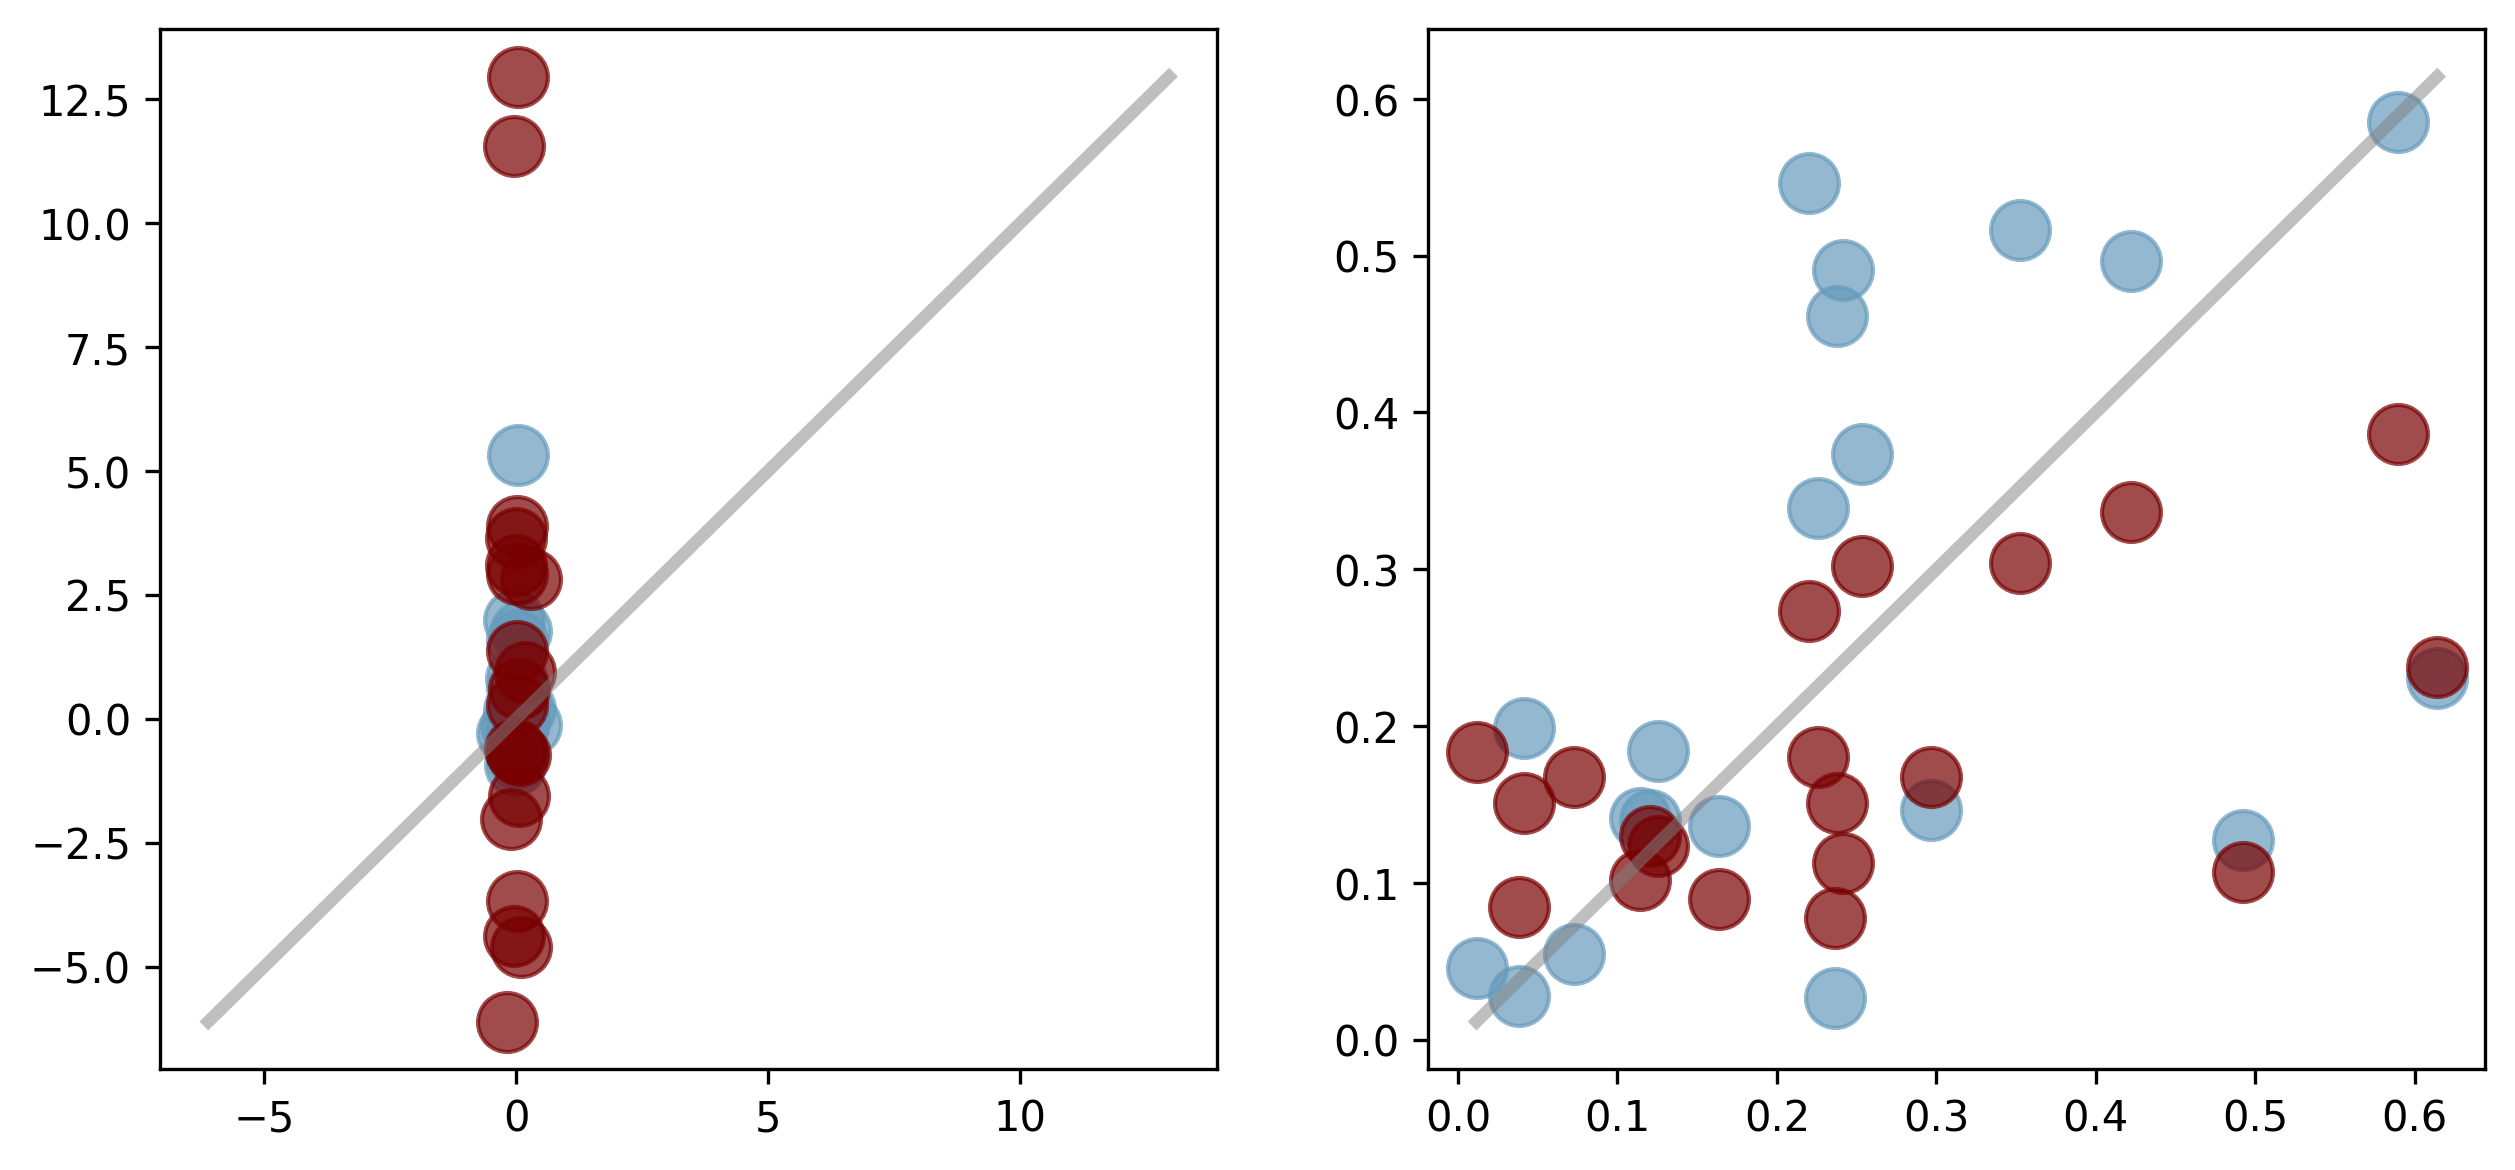

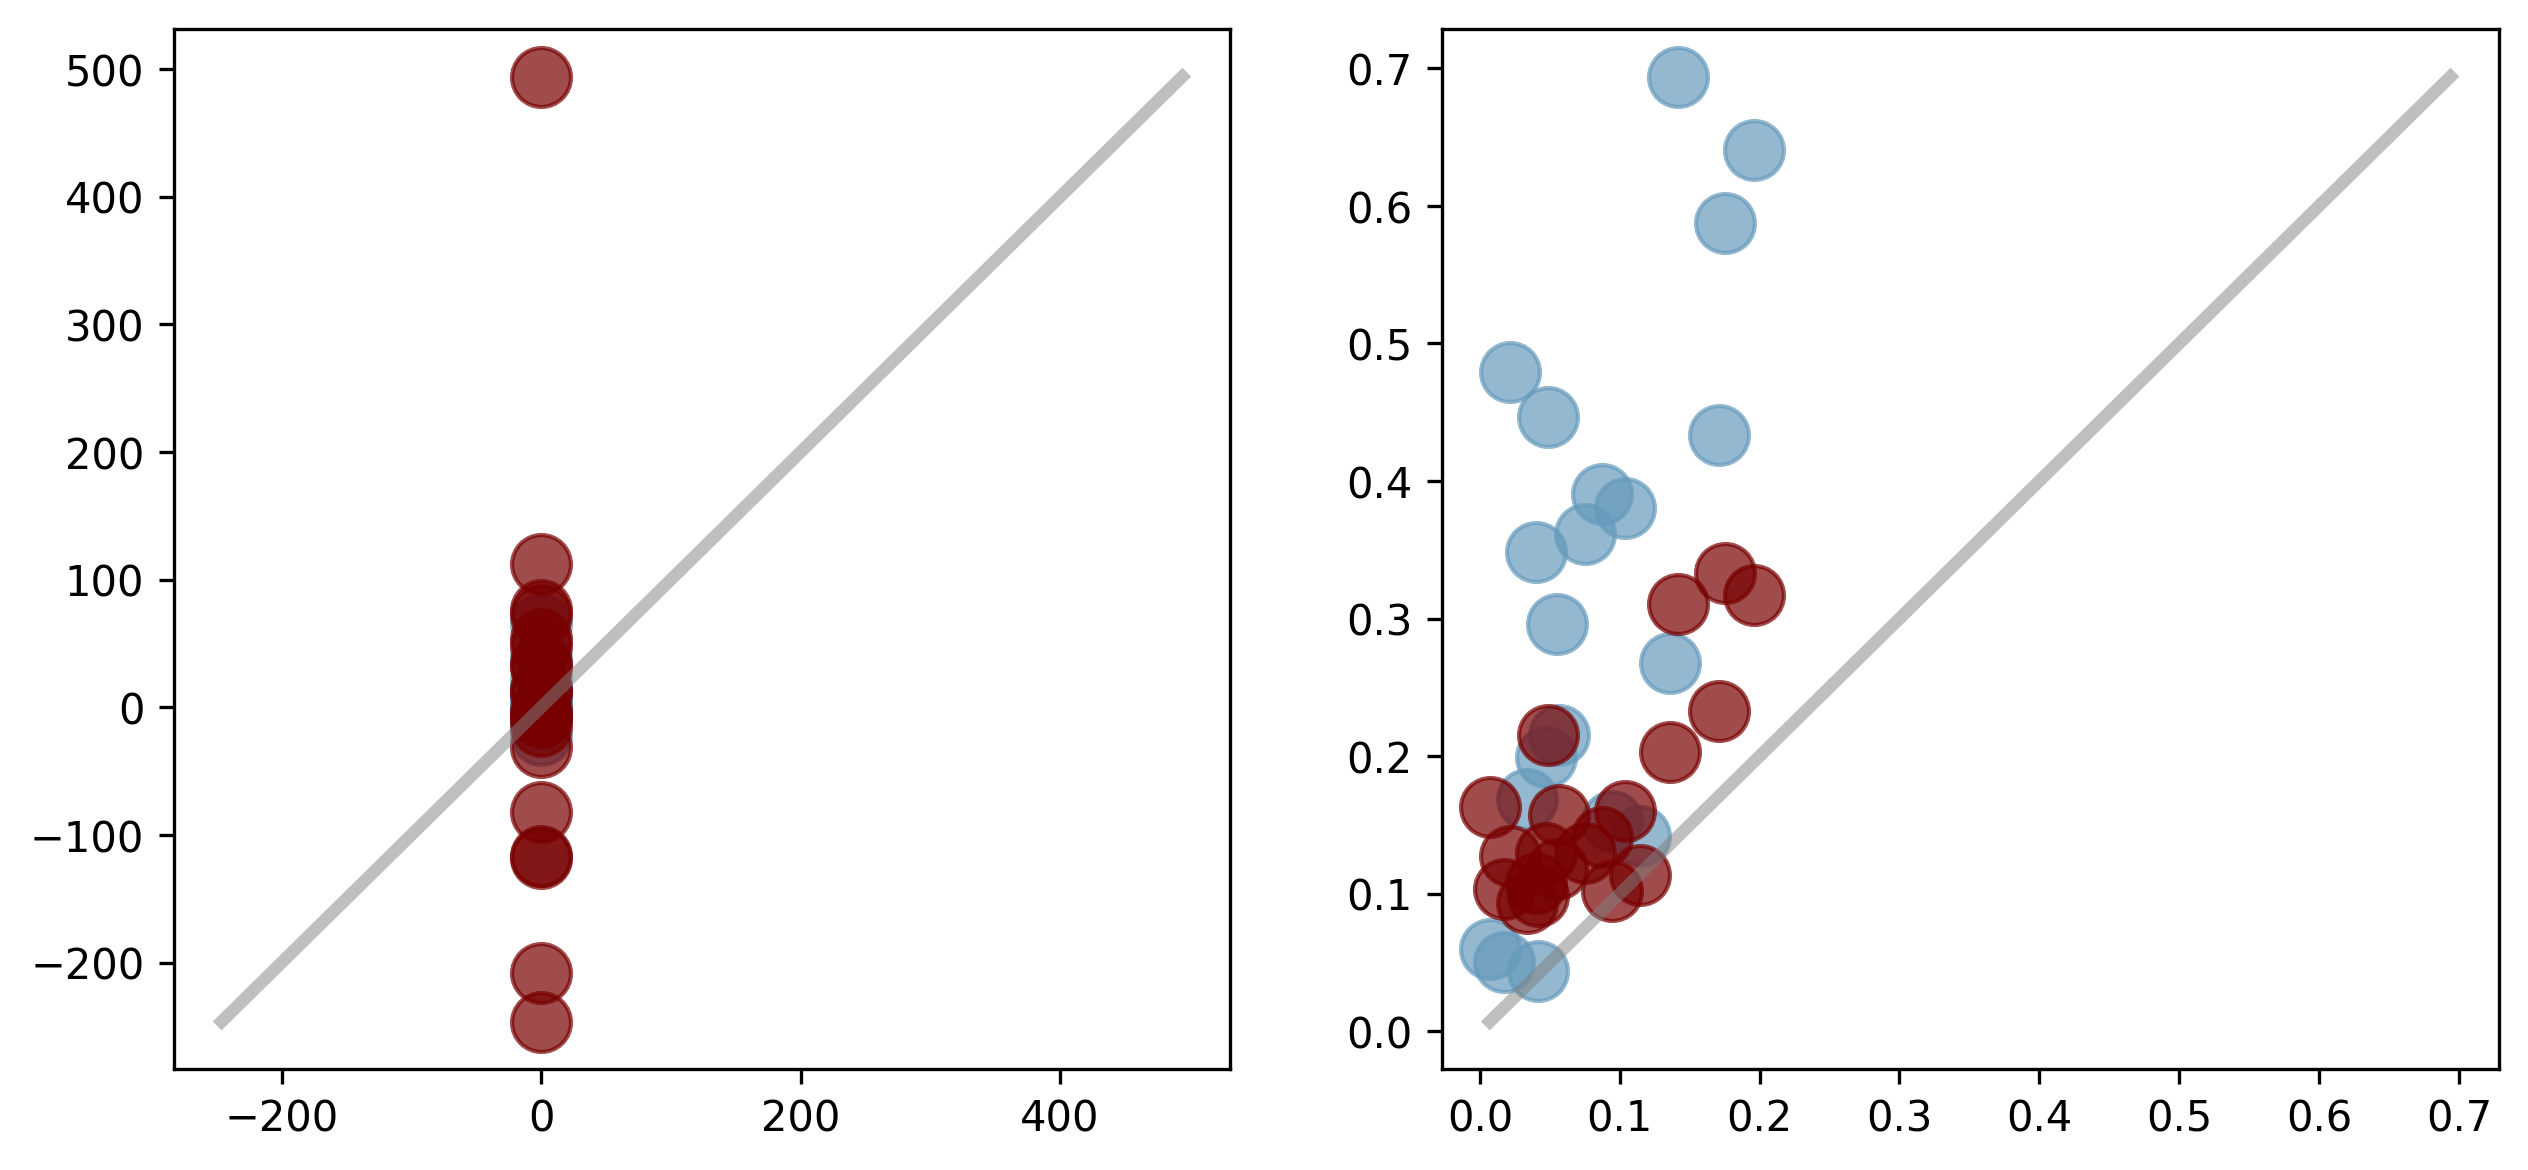

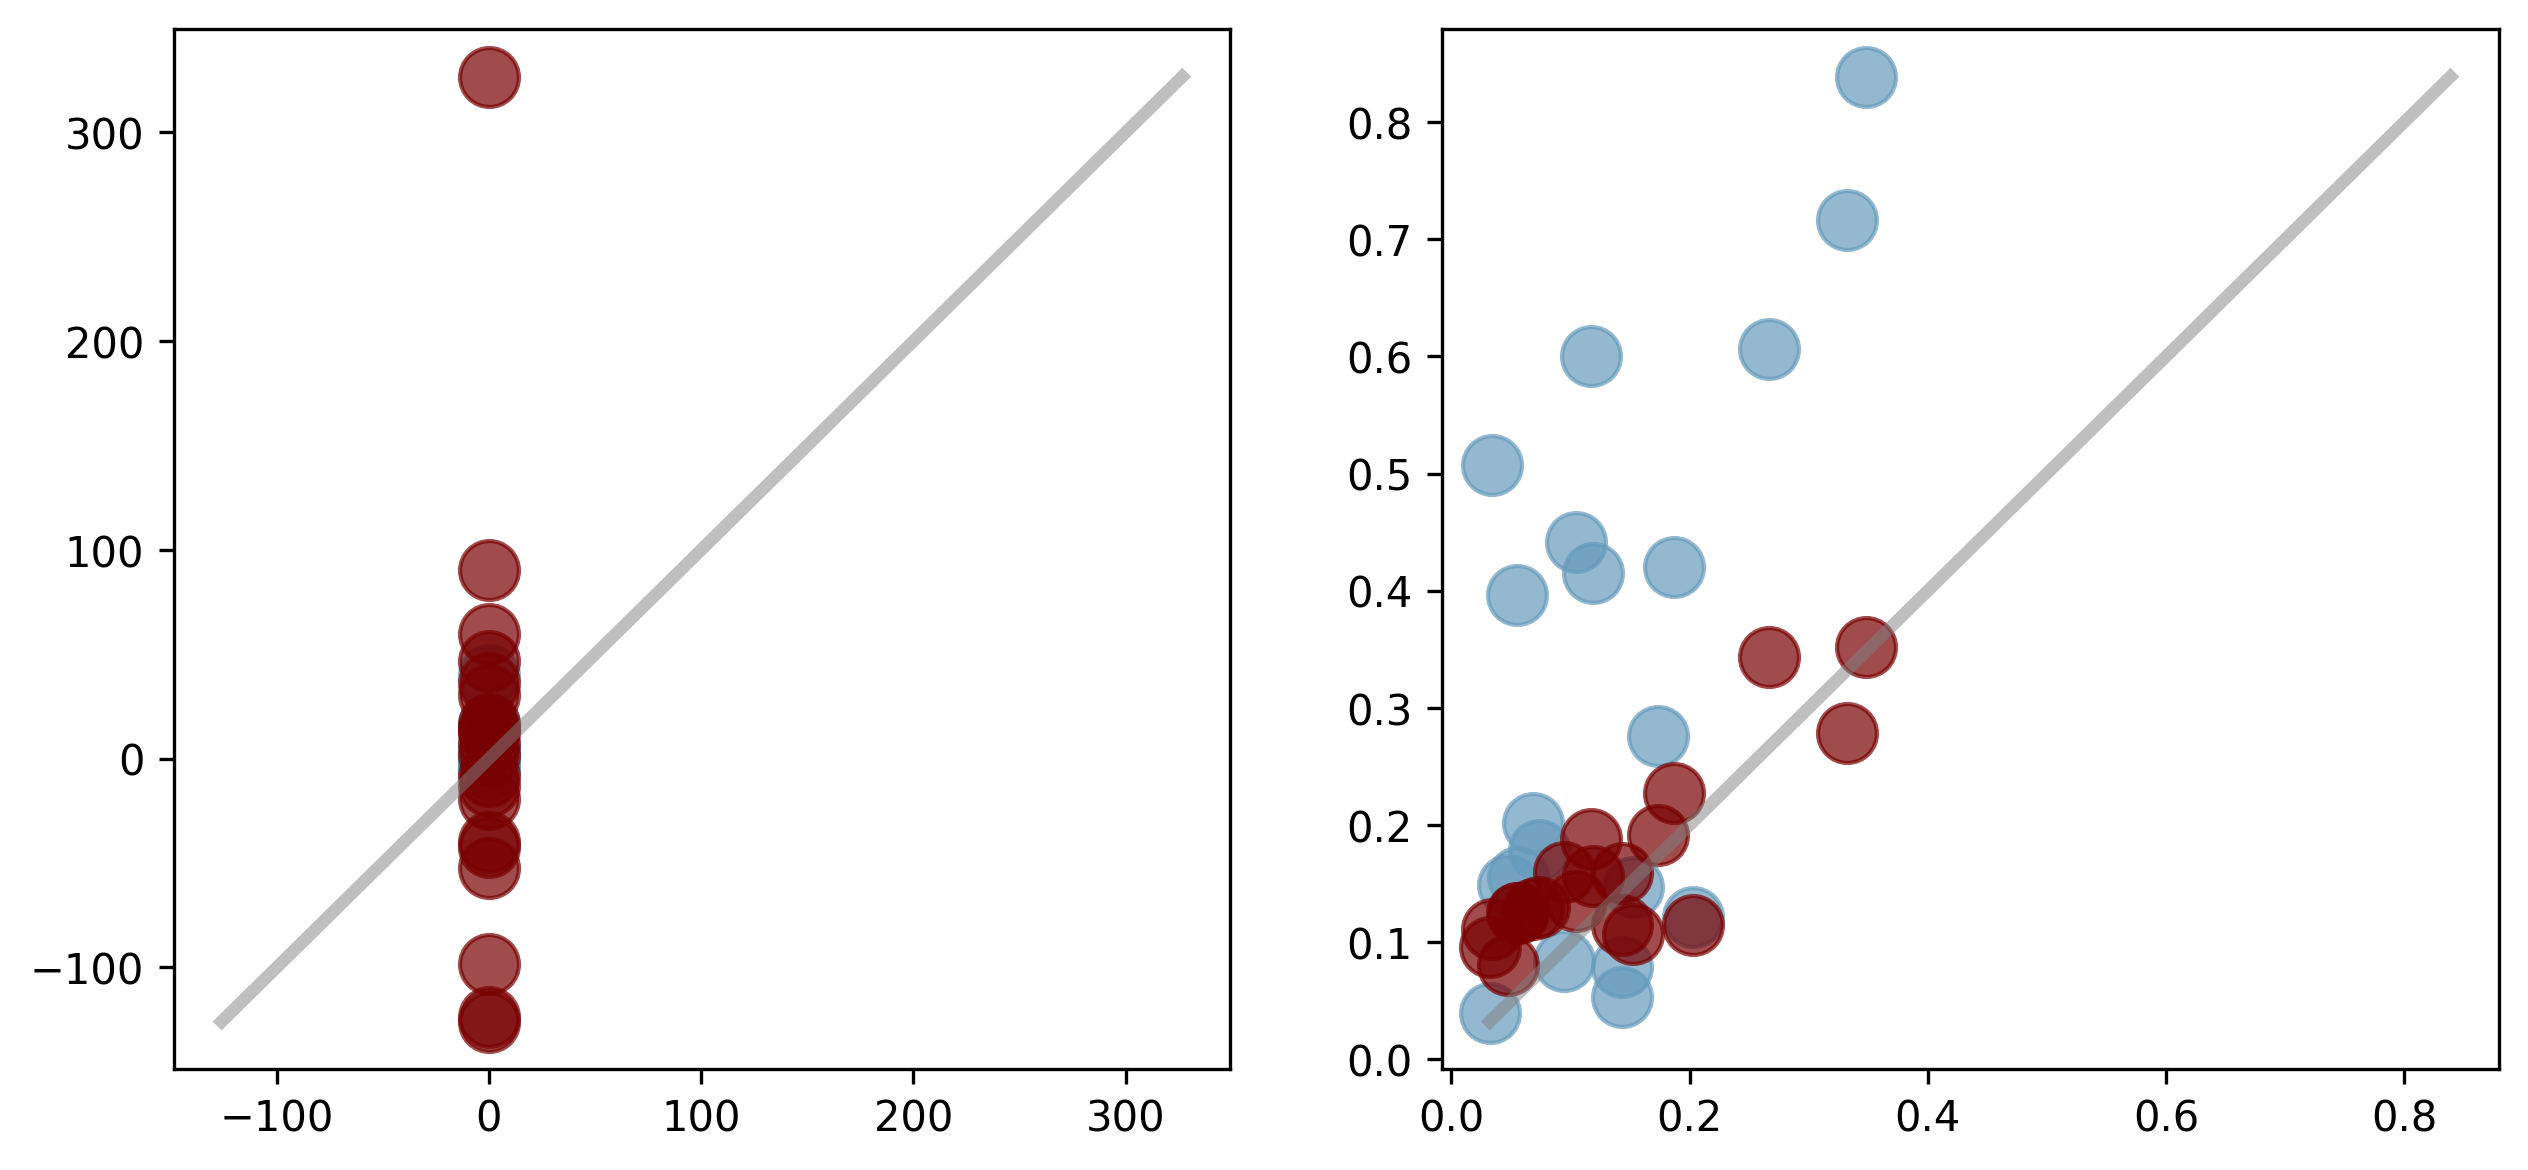

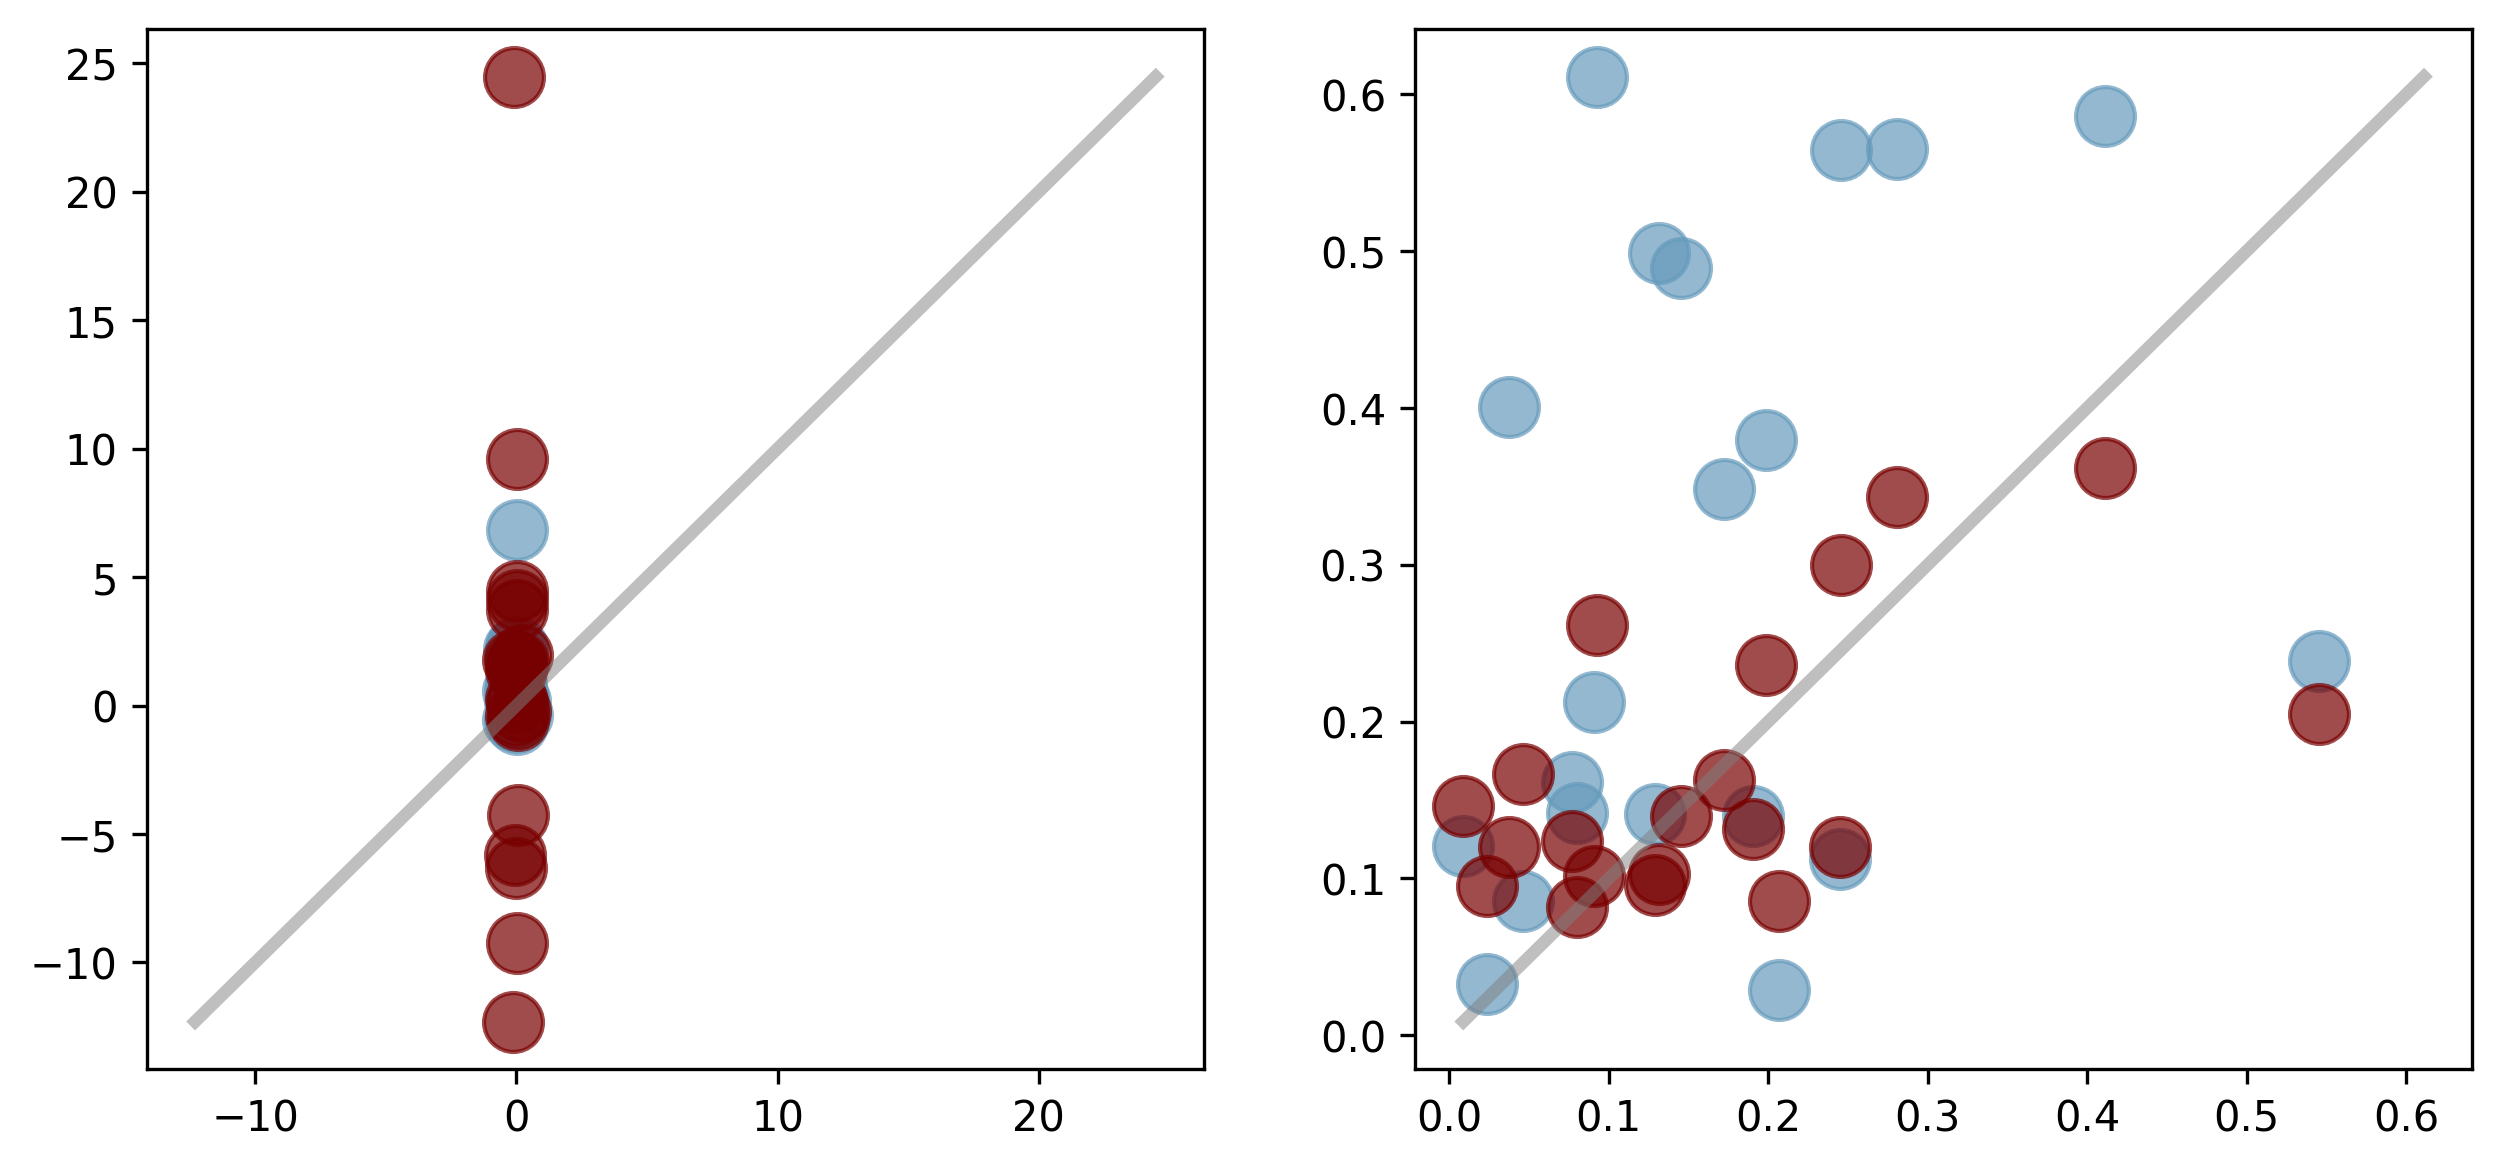

In [28]:
# ---- Colors per loop ----
color_loop1 = '#669bbc'   # light blue
color_loop2 = '#780000'   # dark red

# ---- Prepare Pairs ----
for exp_num in range(real_marker_std.shape[0]):
    # ---- Retrieve mean value of markers -----
    x_mean = real_marker_mean[exp_num]
    x_loop1_mean = loop1_marker_mean[exp_num]
    x_loop2_mean = loop2_marker_mean[exp_num]

    # ---- Retrieve std value of markers -----
    x_std = real_marker_std[exp_num]
    x_loop1_std = loop1_marker_std[exp_num]
    x_loop2_std = loop2_marker_std[exp_num]

    # ---- Smaller figure (4.5 x 4.5 inches) ----
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=300)
    ax_mean, ax_std = ax

    ax_mean.scatter(x_mean, x_loop1_mean, color=color_loop1, alpha=0.7, s=200, label='_nolegend_')
    ax_mean.scatter(x_mean, x_loop2_mean, color=color_loop2, alpha=0.7, s=200, label='_nolegend_')

    ax_std.scatter(x_std, x_loop1_std, color=color_loop1, alpha=0.7, s=200, label='_nolegend_')
    ax_std.scatter(x_std, x_loop2_std, color=color_loop2, alpha=0.7, s=200, label='_nolegend_')

    # ---- Diagonal reference line for mean ----
    all_vals = np.concatenate([x_mean, x_loop1_mean, x_loop2_mean])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax_mean.plot([min_val, max_val], [min_val, max_val], linewidth=3, alpha=0.5, label='_nolegend_',color="gray")

    # ---- Diagonal reference line for std ----
    all_vals = np.concatenate([x_std, x_loop1_std, x_loop2_std])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax_std.plot([min_val, max_val], [min_val, max_val], linewidth=3, alpha=0.5, label='_nolegend_',color="gray")


### Plot Marker Statistics in Transformed Space.

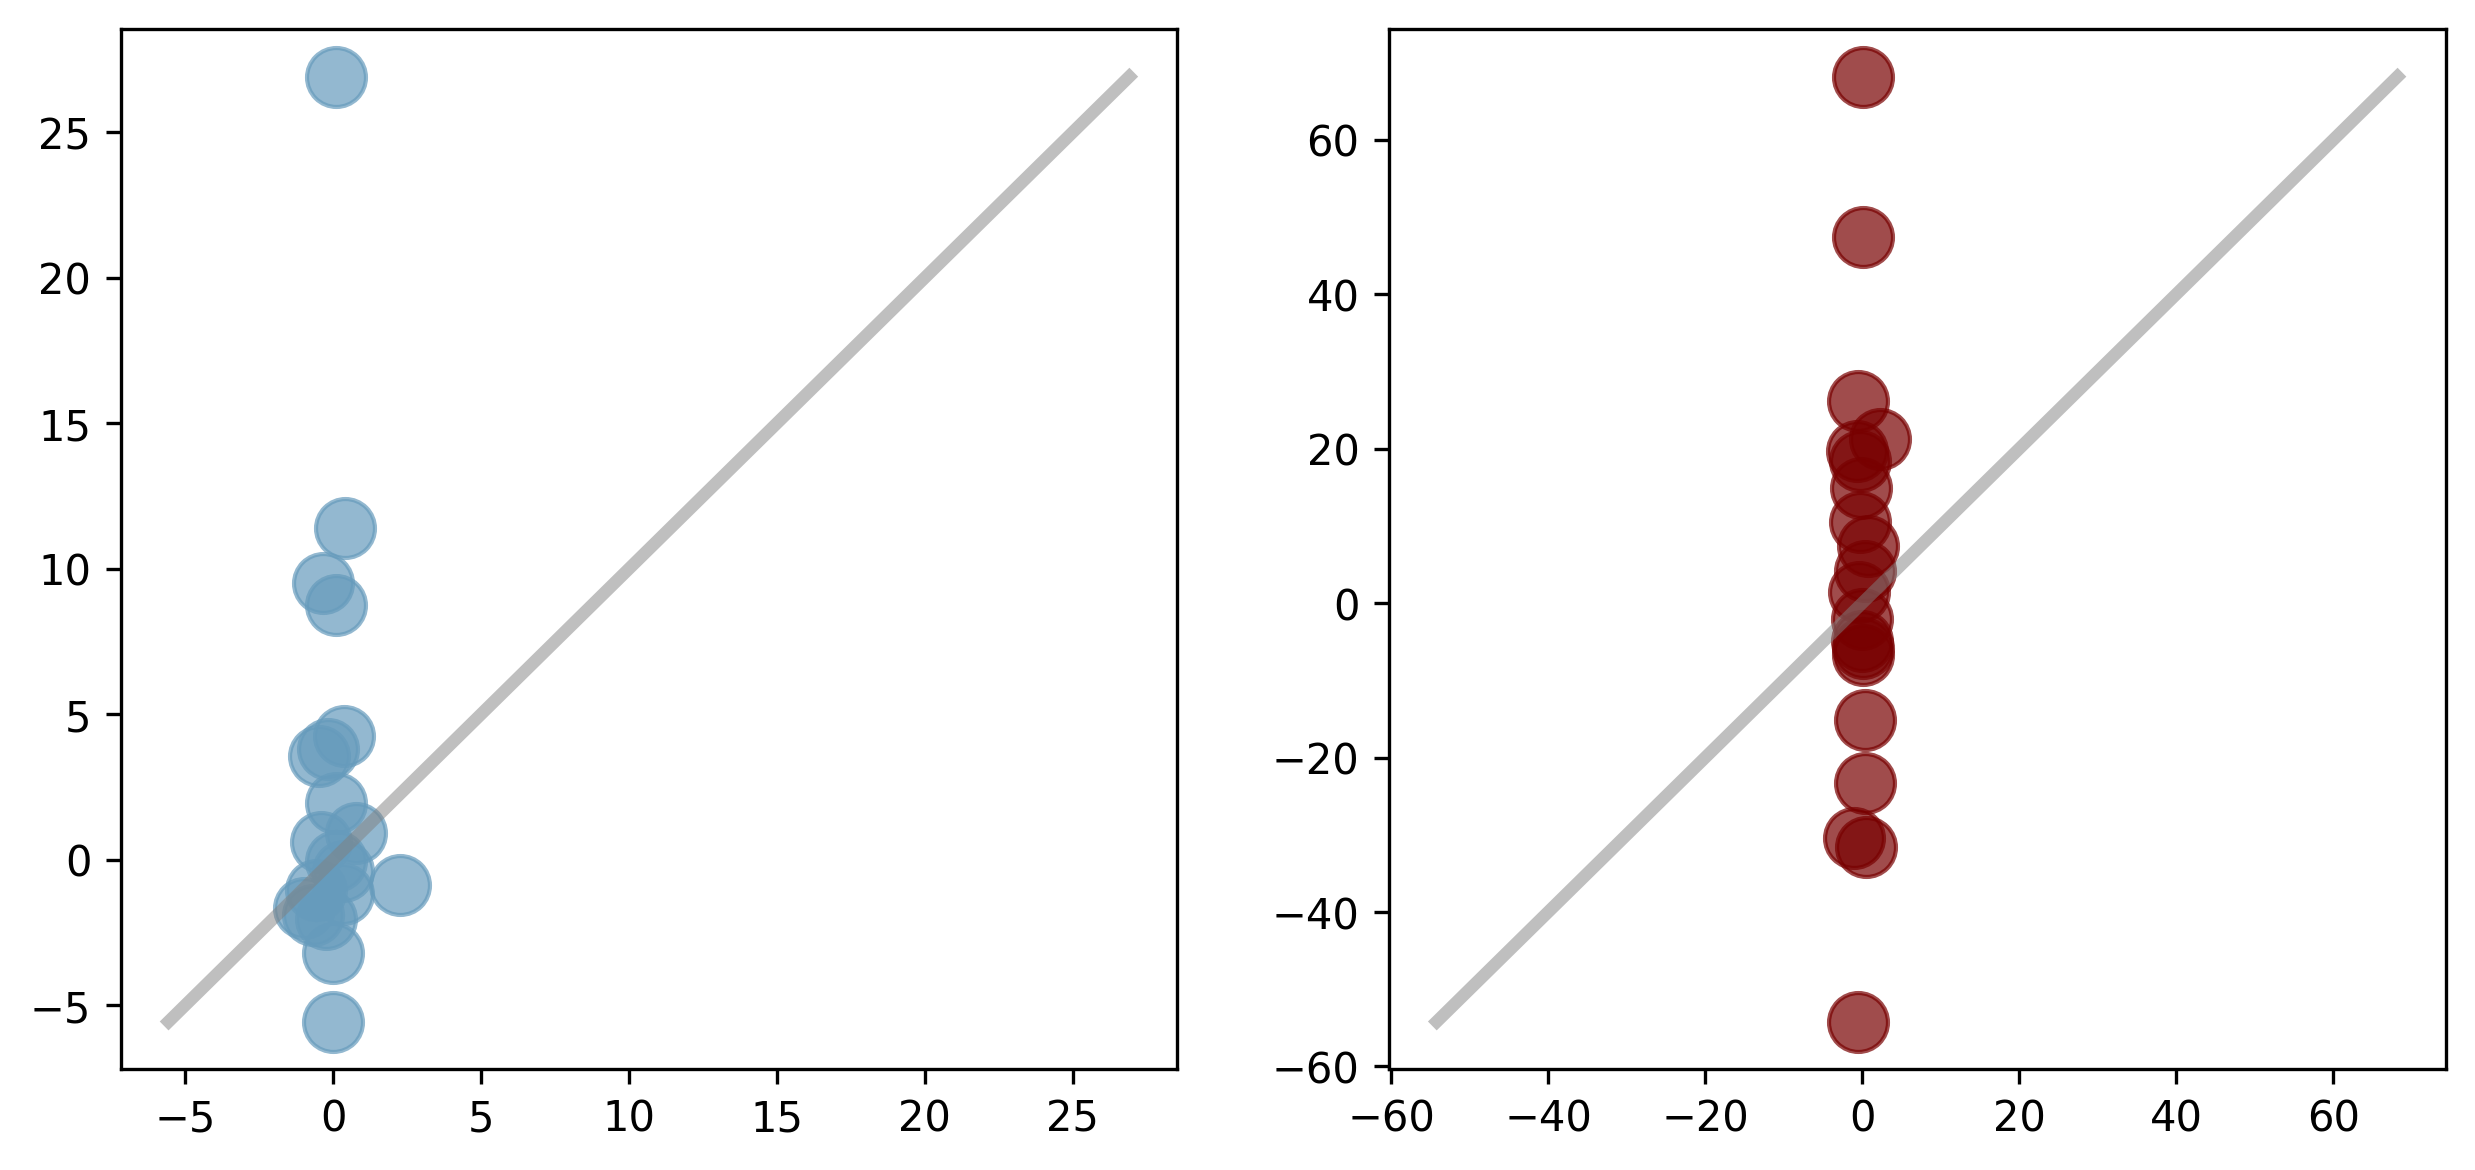

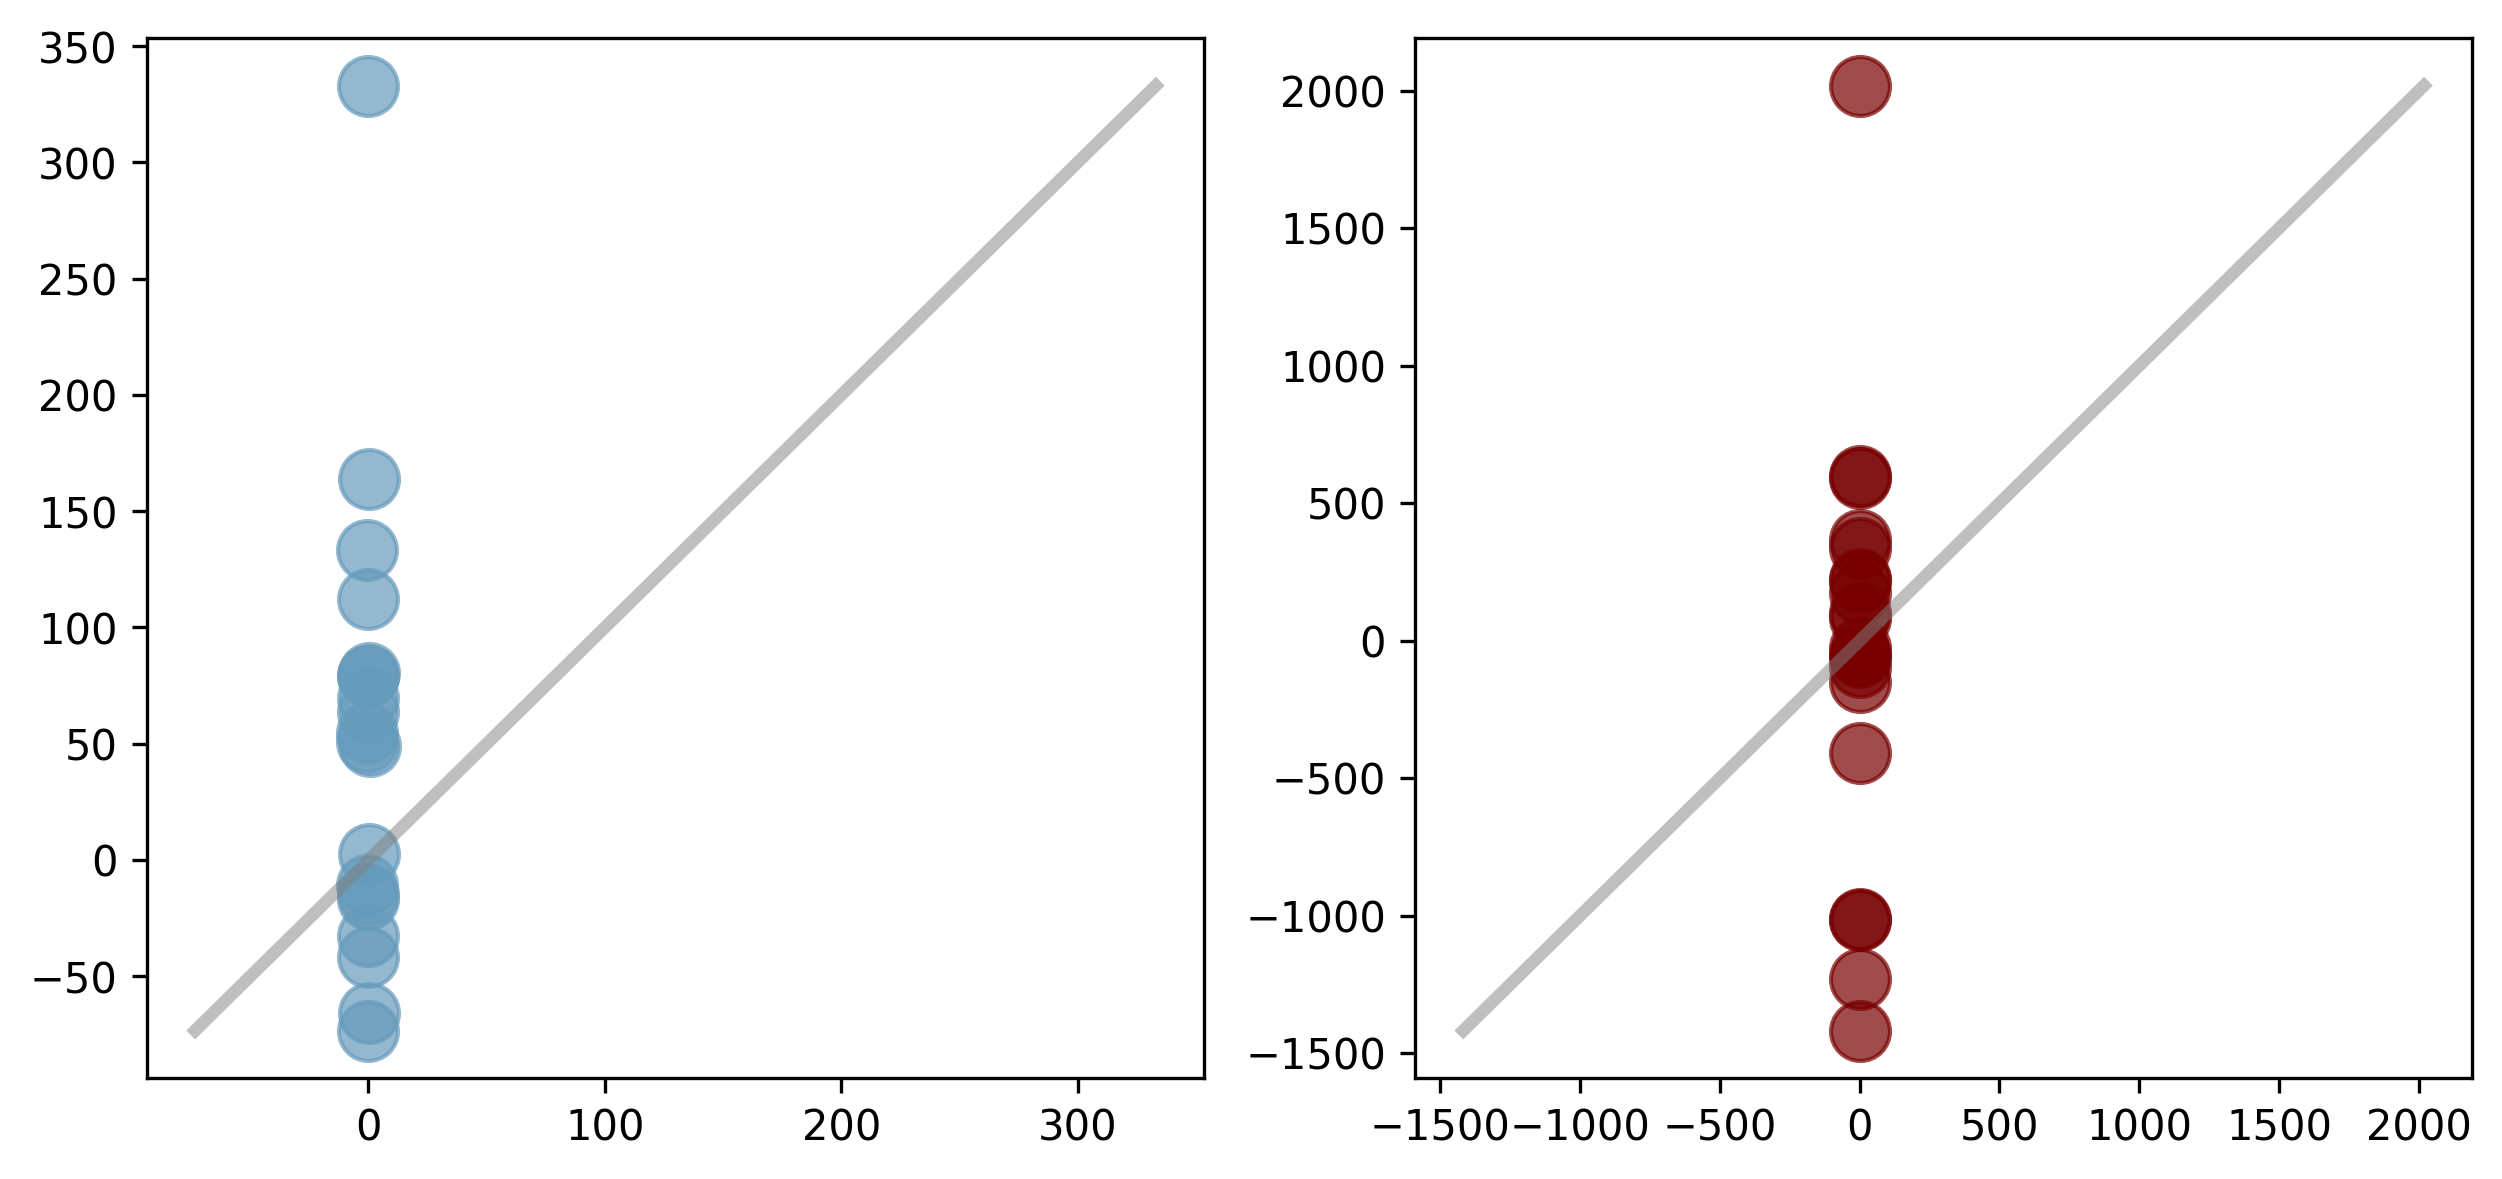

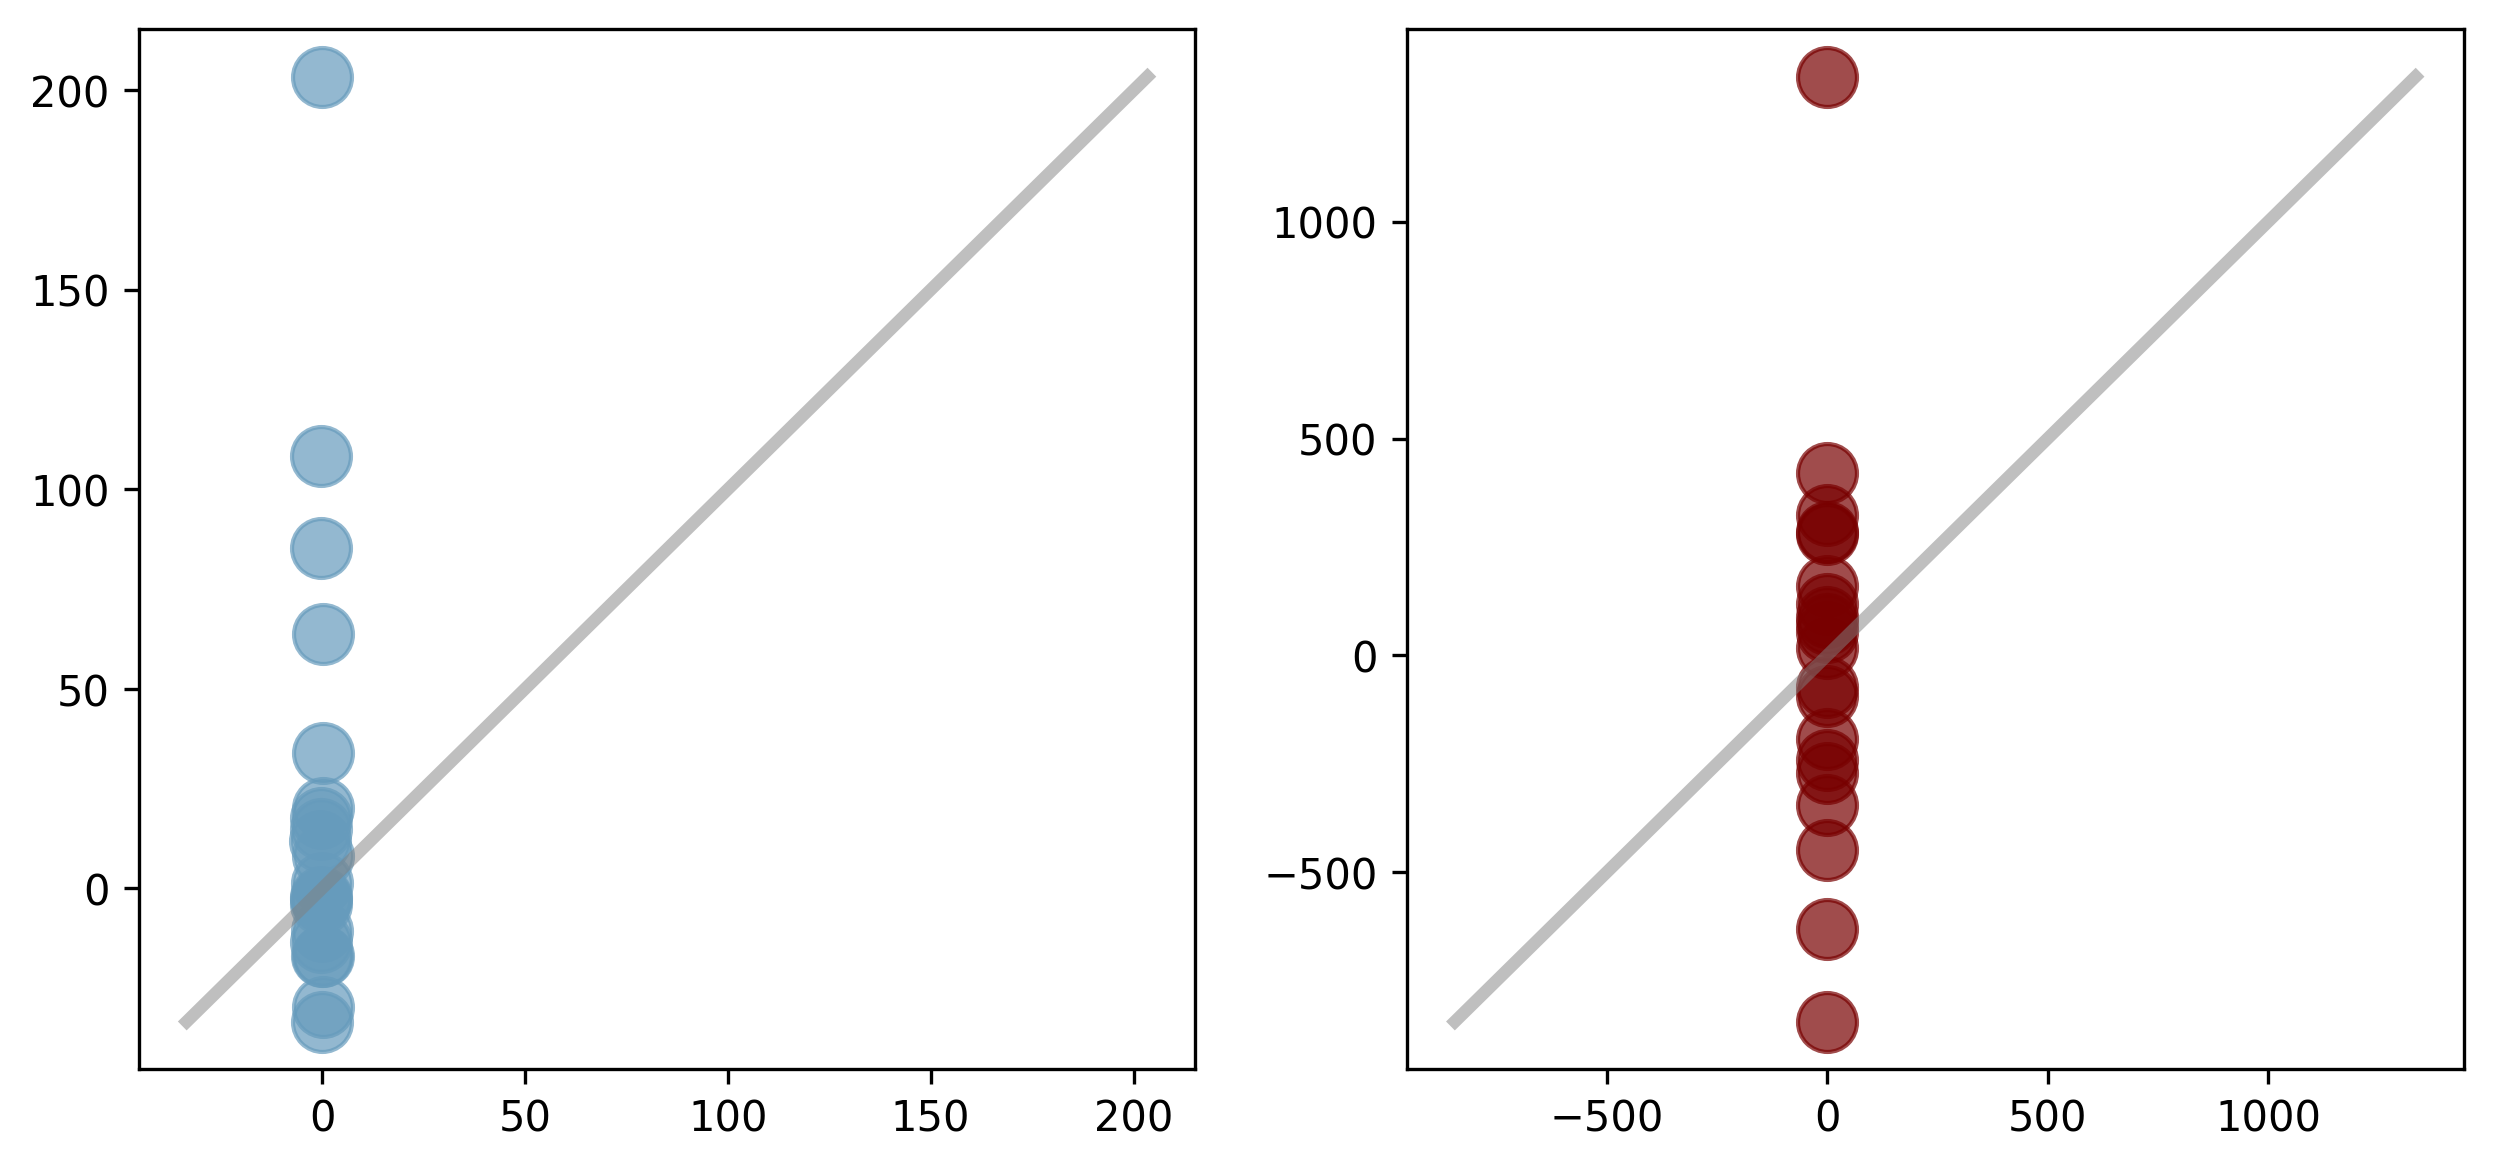

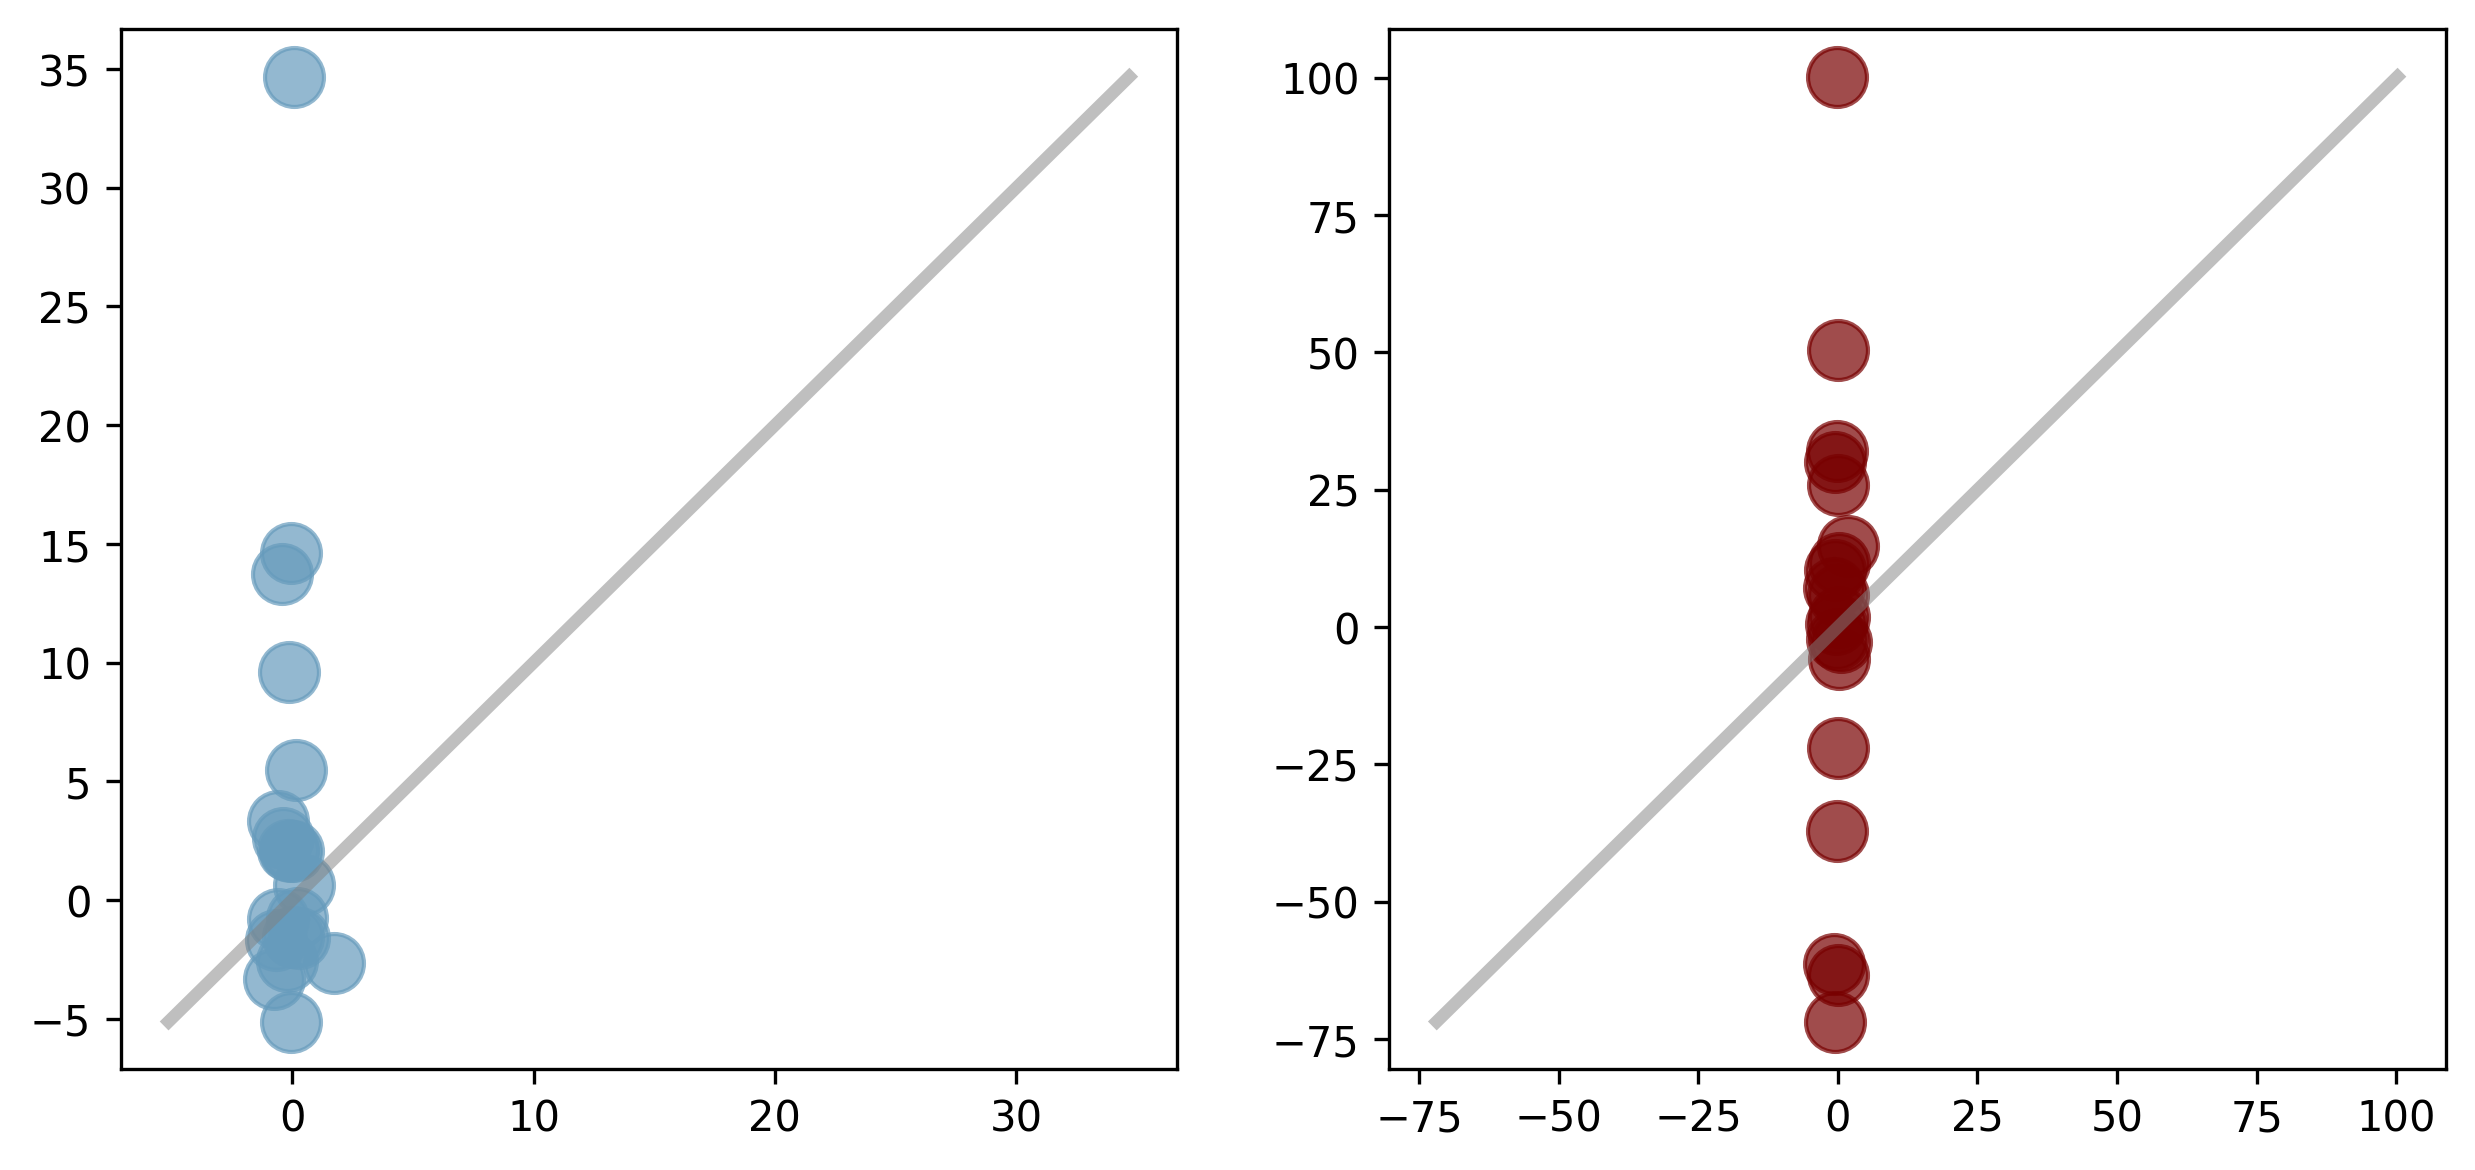

In [29]:
# ---- Colors per loop ----
color_loop1 = '#669bbc'   # light blue
color_loop2 = '#780000'   # dark red

# ---- Prepare Pairs ----
for exp_num in range(real_marker_std.shape[0]):
    # ---- Retrieve mean value of markers -----
    x_mean_transf1 = real_marker_mean_transf1[exp_num]
    x_mean_transf2 = real_marker_mean_transf1[exp_num]
    x_loop1_mean_transf = loop1_marker_mean_transf[exp_num]
    x_loop2_mean_transf = loop2_marker_mean_transf[exp_num]

    # ---- Smaller figure (4.5 x 4.5 inches) ----
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.5), dpi=300)
    ax_loop1, ax_loop2 = ax

    ax_loop1.scatter(x_mean_transf1, x_loop1_mean_transf, color=color_loop1, alpha=0.7, s=200, label='_nolegend_')
    ax_loop2.scatter(x_mean_transf2, x_loop2_mean_transf, color=color_loop2, alpha=0.7, s=200, label='_nolegend_')

    # ---- Diagonal reference line for loop 1 ----
    all_vals = np.concatenate([x_mean_transf1, x_loop1_mean_transf])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax_loop1.plot([min_val, max_val], [min_val, max_val], linewidth=3, alpha=0.5, label='_nolegend_',color="gray")

    # ---- Diagonal reference line for std ----
    all_vals = np.concatenate([x_mean_transf2, x_loop2_mean_transf])
    min_val, max_val = all_vals.min(), all_vals.max()
    ax_loop2.plot([min_val, max_val], [min_val, max_val], linewidth=3, alpha=0.5, label='_nolegend_',color="gray")
